In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

In [4]:
df = pd.read_csv("run_results.csv")

In [5]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time,rng_seed
count,2023.000000,2023.0,2023.000000,2023.000000,2023.000000,2023.0,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03,...,2.023000e+03,2023.000000,2.023000e+03,2.023000e+03,2023.000000,2.023000e+03,2023.000000,2023.000000,2023.000000,2023.000000
mean,283.254572,24.0,82.791893,4.476520,1133.018290,32128.0,9.100403e+06,9.100403e+06,9.100403e+06,1.470586e+05,...,1.932061e-04,0.027362,1.932061e-04,4.830152e-05,0.027362,1.932061e-04,6.030212,5.207196,21276.421718,1.723183
std,258.570195,0.0,44.089152,5.688529,1034.280782,0.0,8.307343e+06,8.307343e+06,8.307343e+06,2.641525e+05,...,3.547733e-04,0.038415,3.547733e-04,8.869333e-05,0.038415,3.547733e-04,20.361407,18.262852,31660.861716,8.332987
min,32.000000,24.0,32.000000,1.000000,128.000000,32128.0,1.028096e+06,1.028096e+06,1.028096e+06,1.024000e+03,...,9.536743e-07,0.000977,9.536743e-07,2.384186e-07,0.000977,9.536743e-07,2.975324,2.975324,114.124368,0.000000
25%,128.000000,24.0,32.000000,1.000000,512.000000,32128.0,4.112384e+06,4.112384e+06,4.112384e+06,1.638400e+04,...,1.779982e-05,0.003906,1.779982e-05,4.449955e-06,0.003906,1.779982e-05,3.510009,3.509797,834.181332,0.000000
50%,256.000000,24.0,64.000000,2.000000,1024.000000,32128.0,8.224768e+06,8.224768e+06,8.224768e+06,6.553600e+04,...,5.651091e-05,0.013602,5.651091e-05,1.412773e-05,0.013602,5.651091e-05,4.229978,4.112712,10855.269162,0.000000
75%,512.000000,24.0,128.000000,4.000000,2048.000000,32128.0,1.644954e+07,1.644954e+07,1.644954e+07,2.621440e+05,...,1.937745e-04,0.039373,1.937745e-04,4.844364e-05,0.039373,1.937745e-04,5.208618,4.770609,26970.843696,0.000000
max,1024.000000,24.0,128.000000,32.000000,4096.000000,32128.0,3.289907e+07,3.289907e+07,3.289907e+07,1.048576e+06,...,2.278377e-03,0.250000,2.278377e-03,5.695943e-04,0.250000,2.278377e-03,374.245812,374.018747,169222.904452,42.000000


In [6]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_step', 'n_warmup_step',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time',
       'lr_schedule_mode', 'rng_seed'],
      dtype='object')


In [7]:
# calculate effective learning rate (base_lr * sqrt(n_training_tokens))
df['effective_lr'] = df['base_lr'] * np.sqrt(df['n_training_tokens'])

In [8]:
df_32 = df[df['head_dimension'] == 32]
df_128 = df[df['head_dimension'] == 128]

In [9]:
print(df['n_pretrain_step'].unique())
print(df['n_training_tokens'].unique())
print(df['n_parameters'].unique())
print(df['lr_schedule_mode'].unique())

[89208.  3591.  9342. 27324.   696.  1526.]
[5.84630272e+09 2.35335680e+08 6.12229120e+08 1.79068928e+09
 4.55628800e+07 9.99731200e+07]
[ 11766784  30611456  89534464 292315136   2278144   4998656]
['clipping' 'relative']


In [10]:
print(df_32[df_32['n_pretrain_step'] == 696]['training_wall_time'].mean())
print(df_32.query('n_pretrain_step == 89208 & d_model == 32')['training_wall_time'].mean())

128.04290715555555
9623.636426444444


In [11]:
training_times = df_32.groupby(['d_model', 'n_pretrain_step'])['training_wall_time']
print(training_times.describe())

                         count           mean           std            min  \
d_model n_pretrain_step                                                      
32      696.0             90.0     128.042907     29.890087     114.124368   
        89208.0           45.0    9623.636426    973.540907    8228.979271   
64      1526.0            90.0     374.540185    120.687232     323.493395   
        89208.0           45.0   17701.484016   5129.778743   16250.050457   
128     3591.0            90.0    1303.109488    222.645402    1244.489930   
        89208.0           45.0   30212.672027   3484.924828   29359.922941   
256     9342.0            90.0    6040.343139   1180.072723    5887.549130   
        89208.0           45.0   55867.514227    110.313106   55600.971679   
512     27324.0           90.0   36155.234458   9230.939447   30854.150686   
        89208.0           45.0  112943.997504    189.898480  112535.114050   
1024    89208.0           45.0   71836.056196  23022.250270   18

In [12]:
df_32['flops'] = 64 * 1024 * 6 * df_32['n_parameters'] * df_32['n_pretrain_step']
training_flops = df_32.groupby(['d_model', 'n_pretrain_step'])['flops']
print(training_flops.describe())

                         count          mean  std           min           25%  \
d_model n_pretrain_step                                                         
32      696.0             90.0  6.234787e+14  0.0  6.234787e+14  6.234787e+14   
        89208.0           45.0  7.991276e+16  0.0  7.991276e+16  7.991276e+16   
64      1526.0            90.0  2.999432e+15  0.0  2.999432e+15  2.999432e+15   
        89208.0           45.0  1.753429e+17  0.0  1.753429e+17  1.753429e+17   
128     3591.0            90.0  1.661515e+16  0.0  1.661515e+16  1.661515e+16   
        89208.0           45.0  4.127554e+17  0.0  4.127554e+17  4.127554e+17   
256     9342.0            90.0  1.124489e+17  0.0  1.124489e+17  1.124489e+17   
        89208.0           45.0  1.073789e+18  0.0  1.073789e+18  1.073789e+18   
512     27324.0           90.0  9.619792e+17  0.0  9.619792e+17  9.619792e+17   
        89208.0           45.0  3.140691e+18  0.0  3.140691e+18  3.140691e+18   
1024    89208.0           45

C:\Users\luigi\AppData\Local\Temp\ipykernel_31920\4214822864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_32['flops'] = 64 * 1024 * 6 * df_32['n_parameters'] * df_32['n_pretrain_step']


In [13]:
training_tokens = df_32.groupby(['d_model', 'n_pretrain_step'])['n_training_tokens']
print(training_tokens.describe())

                         count          mean  std           min           25%  \
d_model n_pretrain_step                                                         
32      696.0             90.0  4.556288e+07  0.0  4.556288e+07  4.556288e+07   
        89208.0           45.0  5.846303e+09  0.0  5.846303e+09  5.846303e+09   
64      1526.0            90.0  9.997312e+07  0.0  9.997312e+07  9.997312e+07   
        89208.0           45.0  5.846303e+09  0.0  5.846303e+09  5.846303e+09   
128     3591.0            90.0  2.353357e+08  0.0  2.353357e+08  2.353357e+08   
        89208.0           45.0  5.846303e+09  0.0  5.846303e+09  5.846303e+09   
256     9342.0            90.0  6.122291e+08  0.0  6.122291e+08  6.122291e+08   
        89208.0           45.0  5.846303e+09  0.0  5.846303e+09  5.846303e+09   
512     27324.0           90.0  1.790689e+09  0.0  1.790689e+09  1.790689e+09   
        89208.0           45.0  5.846303e+09  0.0  5.846303e+09  5.846303e+09   
1024    89208.0           45

In [14]:
def create_best_runs_dfs(df: pd.DataFrame):
    df = df.copy()
    # create column that states whether model was trained to full length or not
    df['full_length_training'] = df['n_training_tokens'] == 5.84630272e+09

    # split into relative and not relative df
    df_relative = df[df['lr_schedule_mode'] == 'relative']
    df_not_relative = df[df['lr_schedule_mode'] != "relative"]

    # take best runs for each learning rate (different initialization variances)
    df_best_runs_not_relative = (
        df_not_relative
        .sort_values(by="final_loss", ascending=True)
        .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
    )
    df_best_runs_relative = (
        df_relative
        .sort_values(by="final_loss", ascending=True)
        .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
    )

    # take optimal lr for optimum plotting
    df_optimal_lrs_not_relative = (
        df_best_runs_not_relative
        .sort_values(by="final_loss", ascending=True)
        .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
    )
    df_optimal_lrs_relative = (
        df_best_runs_relative
        .sort_values(by="final_loss", ascending=True)
        .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
    )

    return df_best_runs_not_relative, df_optimal_lrs_not_relative, df_best_runs_relative, df_optimal_lrs_relative

In [15]:
import numpy as np
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import Bbox

def two_row_legend(ax, y_label=1.16, y_swatch=1.08, swatch_halfwidth=0.05,
                    pad_x=0.02, pad_y=0.03, x_offset=0.0):
    fig = ax.figure
    handles, labels = ax.get_legend_handles_labels()
    n = len(labels)
    xs = np.linspace(1/(2*n), 1 - 1/(2*n), n) + x_offset

    artists = []

    for x, h, l in zip(xs, handles, labels):
        color = h.get_color()
        ls = h.get_linestyle()
        lw = h.get_linewidth()
        marker = h.get_marker()
        mfc = h.get_markerfacecolor()
        mec = h.get_markeredgecolor()
        ms = h.get_markersize()

        txt = ax.annotate(
            l, xy=(x, y_label), xycoords='axes fraction',
            ha='center', va='bottom', clip_on=False,
            zorder=5
        )
        artists.append(txt)

        line, = ax.plot(
            [x - swatch_halfwidth, x, x + swatch_halfwidth],
            [y_swatch, y_swatch, y_swatch],
            transform=ax.transAxes,
            color=color, linestyle=ls, linewidth=lw,
            marker=marker, markevery=[1],
            markerfacecolor=mfc, markeredgecolor=mec, markersize=ms,
            clip_on=False, solid_capstyle='butt', zorder=5
        )
        artists.append(line)

    # --- compute bounding box around everything we just drew ---
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    bboxes = [a.get_window_extent(renderer) for a in artists]
    full_bbox = Bbox.union(bboxes)

    # --- NEW: separate absolute x/y padding, in fractions of figure size ---
    pad_x_px = pad_x * fig.bbox.width
    pad_y_px = pad_y * fig.bbox.height

    full_bbox = Bbox.from_extents(
        full_bbox.x0 - pad_x_px, full_bbox.y0 - pad_y_px,
        full_bbox.x1 + pad_x_px, full_bbox.y1 + pad_y_px
    )
    # --- end new block ---

    inv = ax.transAxes.inverted()
    (x0, y0), (x1, y1) = inv.transform(full_bbox)

    box = FancyBboxPatch(
        (x0, y0), x1 - x0, y1 - y0,
        transform=ax.transAxes,
        boxstyle="round,pad=0,rounding_size=0.02",   # set to 0 since padding is handled above already
        facecolor='white', edgecolor='white', linewidth=0.8,
        zorder=4, clip_on=False
    )
    ax.add_patch(box)

# usage
# two_row_legend(ax)
# fig.subplots_adjust(top=0.8)

In [16]:
def two_row_legend_fig(fig, axs, title=None, y_title=0.97, y_label=0.92, y_swatch=0.87,
                        swatch_halfwidth=0.015, pad_x=0.01, pad_y=0.015,
                        x_offset=0.0, spread=1.0, title_fontsize=None):
    positions = [ax.get_position() for ax in axs]
    x0 = min(p.x0 for p in positions)
    x1 = max(p.x1 for p in positions)
    center = (x0 + x1) / 2

    handles, labels = [], []
    for ax in axs:
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break

    n = len(labels)
    width = (x1 - x0) * spread
    xs = center + width * (np.linspace(1/(2*n), 1 - 1/(2*n), n) - 0.5) + x_offset

    artists = []

    if title is not None:
        title_txt = fig.text(
            center, y_title, title,
            ha='center', va='bottom', clip_on=False, zorder=5,
            fontsize=title_fontsize,
        )
        artists.append(title_txt)


    for x, h, l in zip(xs, handles, labels):
        color = h.get_color()
        ls = h.get_linestyle()
        lw = h.get_linewidth()
        marker = h.get_marker()
        mfc = h.get_markerfacecolor()
        mec = h.get_markeredgecolor()
        ms = h.get_markersize()
        txt = fig.text(
            x, y_label, l,
            ha='center', va='bottom', clip_on=False, zorder=5,
        )
        artists.append(txt)
        line = plt.Line2D(
            [x - swatch_halfwidth, x, x + swatch_halfwidth],
            [y_swatch, y_swatch, y_swatch],
            transform=fig.transFigure,
            color=color, linestyle=ls, linewidth=lw,
            marker=marker, markevery=[1],
            markerfacecolor=mfc, markeredgecolor=mec, markersize=ms,
            clip_on=False, solid_capstyle='butt', zorder=5,
        )
        fig.add_artist(line)
        artists.append(line)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bboxes = [a.get_window_extent(renderer) for a in artists]
    full_bbox = Bbox.union(bboxes)

    pad_x_px = pad_x * fig.bbox.width
    pad_y_px = pad_y * fig.bbox.height
    full_bbox = Bbox.from_extents(
        full_bbox.x0 - pad_x_px, full_bbox.y0 - pad_y_px,
        full_bbox.x1 + pad_x_px, full_bbox.y1 + pad_y_px
    )

    inv = fig.transFigure.inverted()
    (fx0, fy0), (fx1, fy1) = inv.transform(full_bbox)
    box = FancyBboxPatch(
        (fx0, fy0), fx1 - fx0, fy1 - fy0,
        transform=fig.transFigure,
        boxstyle="round,pad=0,rounding_size=0.02",
        facecolor='white', edgecolor='black', linewidth=0.8,
        zorder=4, clip_on=False,
    )
    fig.add_artist(box)

In [17]:
def two_row_legend_fig(fig, axs, title=None,
                        title_offset_in=0.18, row_gap_in=0.20, swatch_gap_in=0.18,
                        swatch_halfwidth=0.015, pad_x_in=0.08, pad_y_in=0.06,
                        x_offset=0.0, spread=1.0,
                        title_fontsize=None,
                        top_in=None):
    fig_w, fig_h = fig.get_size_inches()

    positions = [ax.get_position() for ax in axs]
    x0 = min(p.x0 for p in positions)
    x1 = max(p.x1 for p in positions)
    center = (x0 + x1) / 2

    handles, labels = [], []
    for ax in axs:
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break

    n = len(labels)
    width = (x1 - x0) * spread
    xs = center + width * (np.linspace(1/(2*n), 1 - 1/(2*n), n) - 0.5) + x_offset

    # anchor the whole legend a fixed distance (in inches) below the top of the figure,
    # then lay out title/label/swatch rows using fixed inch gaps -> constant absolute size
    y_top = 1 - (top_in / fig_h) if top_in is not None else 0.995
    y_title = y_top
    y_label = y_title - (title_offset_in + row_gap_in) / fig_h if title is not None else y_top
    y_swatch = y_label - swatch_gap_in / fig_h

    artists = []

    if title is not None:
        title_txt = fig.text(
            center, y_title, title,
            ha='center', va='top', clip_on=False, zorder=5,
            fontsize=title_fontsize,
        )
        artists.append(title_txt)

    for x, h, l in zip(xs, handles, labels):
        color = h.get_color(); ls = h.get_linestyle(); lw = h.get_linewidth()
        marker = h.get_marker(); mfc = h.get_markerfacecolor()
        mec = h.get_markeredgecolor(); ms = h.get_markersize()

        txt = fig.text(
            x, y_label, l,
            ha='center', va='bottom', clip_on=False, zorder=5,
        )
        artists.append(txt)

        line = plt.Line2D(
            [x - swatch_halfwidth, x, x + swatch_halfwidth],
            [y_swatch, y_swatch, y_swatch],
            transform=fig.transFigure,
            color=color, linestyle=ls, linewidth=lw,
            marker=marker, markevery=[1],
            markerfacecolor=mfc, markeredgecolor=mec, markersize=ms,
            clip_on=False, solid_capstyle='butt', zorder=5,
        )
        fig.add_artist(line)
        artists.append(line)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bboxes = [a.get_window_extent(renderer) for a in artists]
    full_bbox = Bbox.union(bboxes)

    pad_x_px = (pad_x_in / fig_w) * fig.bbox.width
    pad_y_px = (pad_y_in / fig_h) * fig.bbox.height
    full_bbox = Bbox.from_extents(
        full_bbox.x0 - pad_x_px, full_bbox.y0 - pad_y_px,
        full_bbox.x1 + pad_x_px, full_bbox.y1 + pad_y_px
    )

    inv = fig.transFigure.inverted()
    (fx0, fy0), (fx1, fy1) = inv.transform(full_bbox)
    box = FancyBboxPatch(
        (fx0, fy0), fx1 - fx0, fy1 - fy0,
        transform=fig.transFigure,
        boxstyle="round,pad=0,rounding_size=0.02",
        facecolor='white', edgecolor='black', linewidth=0.8,
        zorder=4, clip_on=False,
    )
    fig.add_artist(box)

In [18]:
def add_row_label(ax, label, x=-0.35, fontweight='bold', fontsize=None):
    ax.text(
        x, 0.5, label,
        transform=ax.transAxes,
        rotation=90, ha='center', va='center',
        fontweight=fontweight, fontsize=fontsize,
        clip_on=False,
    )


In [19]:

df_32_best_runs_not_relative, df_32_optimal_lrs_not_relative, df_32_best_runs_relative, df_32_optimal_lrs_relative = create_best_runs_dfs(df_32)
df_128_best_runs_not_relative, df_128_optimal_lrs_not_relative, df_128_best_runs_relative, df_128_optimal_lrs_relative = create_best_runs_dfs(df_128)


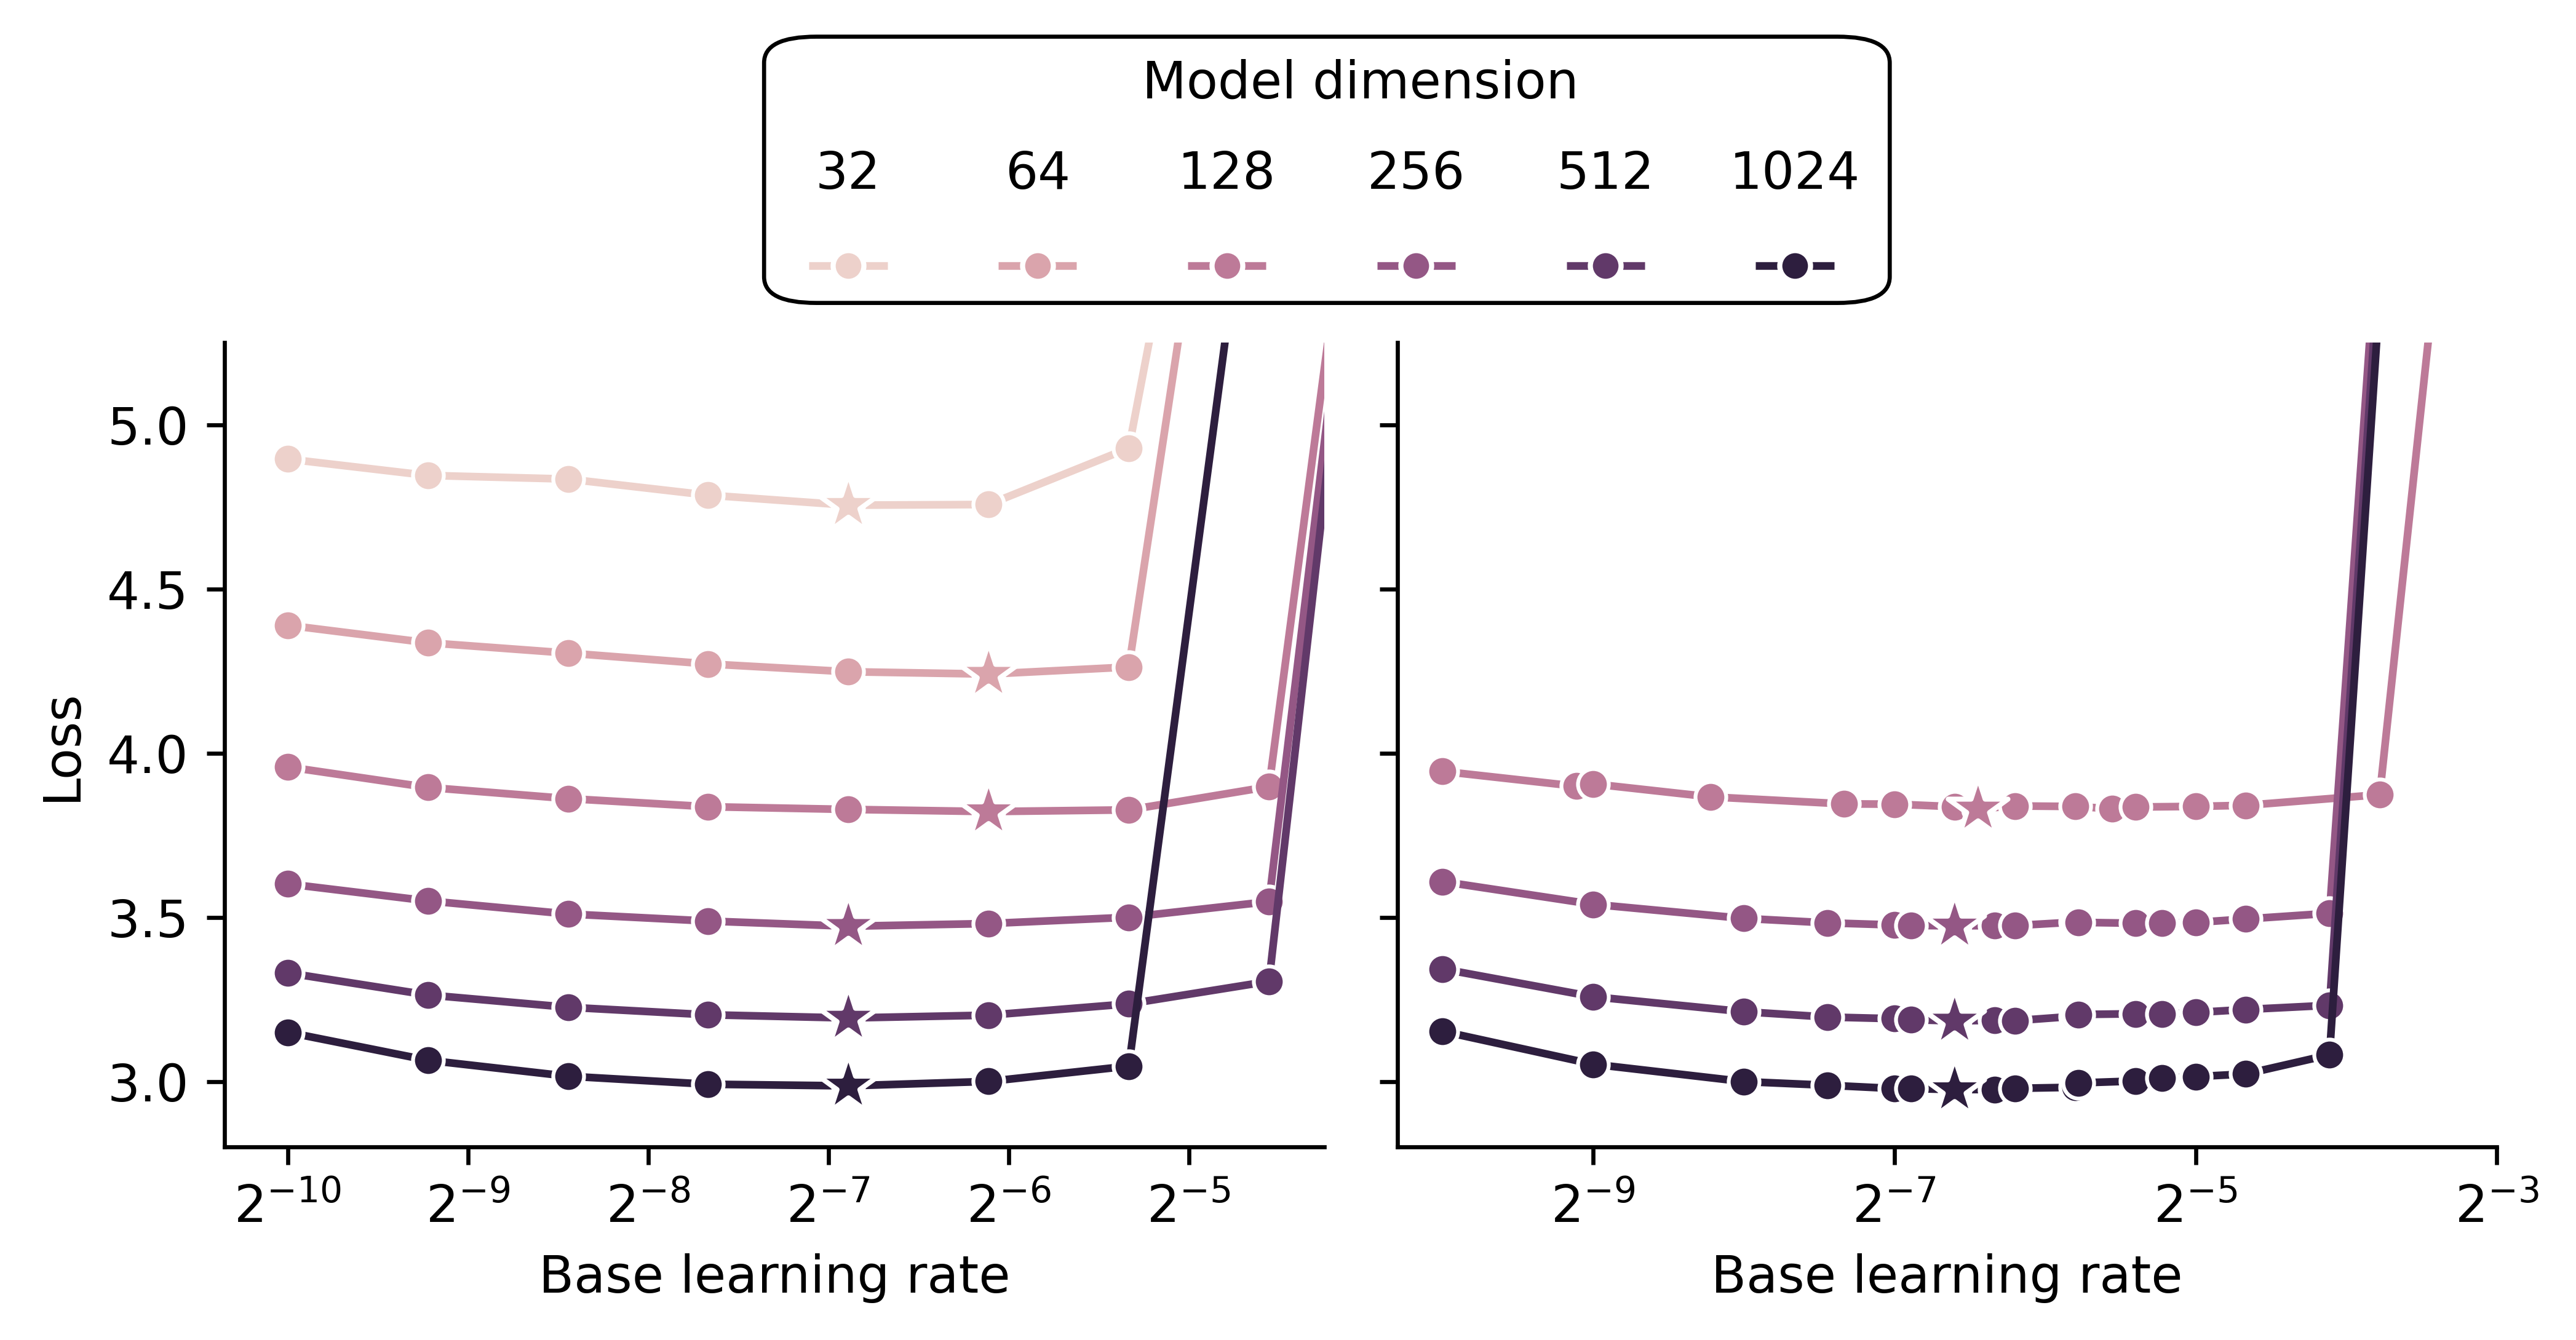

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(3.54 * 2, 3.54), sharey=True, dpi=600)

ax1, ax2 = axs

shared_norm = LogNorm(vmin=32, vmax=1024)

# final loss
sns.lineplot(df_32_best_runs_not_relative.query('full_length_training == True'),
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='o',
    zorder=1,
    )

sns.scatterplot(
    df_32_optimal_lrs_not_relative.query('full_length_training == True'),
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

sns.lineplot(df_128_best_runs_not_relative.query('full_length_training == True'),
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='o',
    zorder=1,
    legend=False,
    )

sns.scatterplot(
    df_128_optimal_lrs_not_relative.query('full_length_training == True'),
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax1.set_xscale('log', base=2)
ax1.set_xlim(2**-10.35, 2**-4.25)
ax1.set_ylim(2.8, 5.25)


ax2.set_xscale('log', base=2)
ax2.set_xlim(2**-10.3, 2**-3)
ax1.set_ylabel('Loss')
ax1.set_xlabel('Base learning rate')
ax2.set_xlabel('Base learning rate')


# fig.subplots_adjust(top=0.8)  # leave room above the axes
fig.tight_layout(rect=[0, 0, 1, 0.82])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()


sns.despine()
# plt.tight_layout()
plt.show()

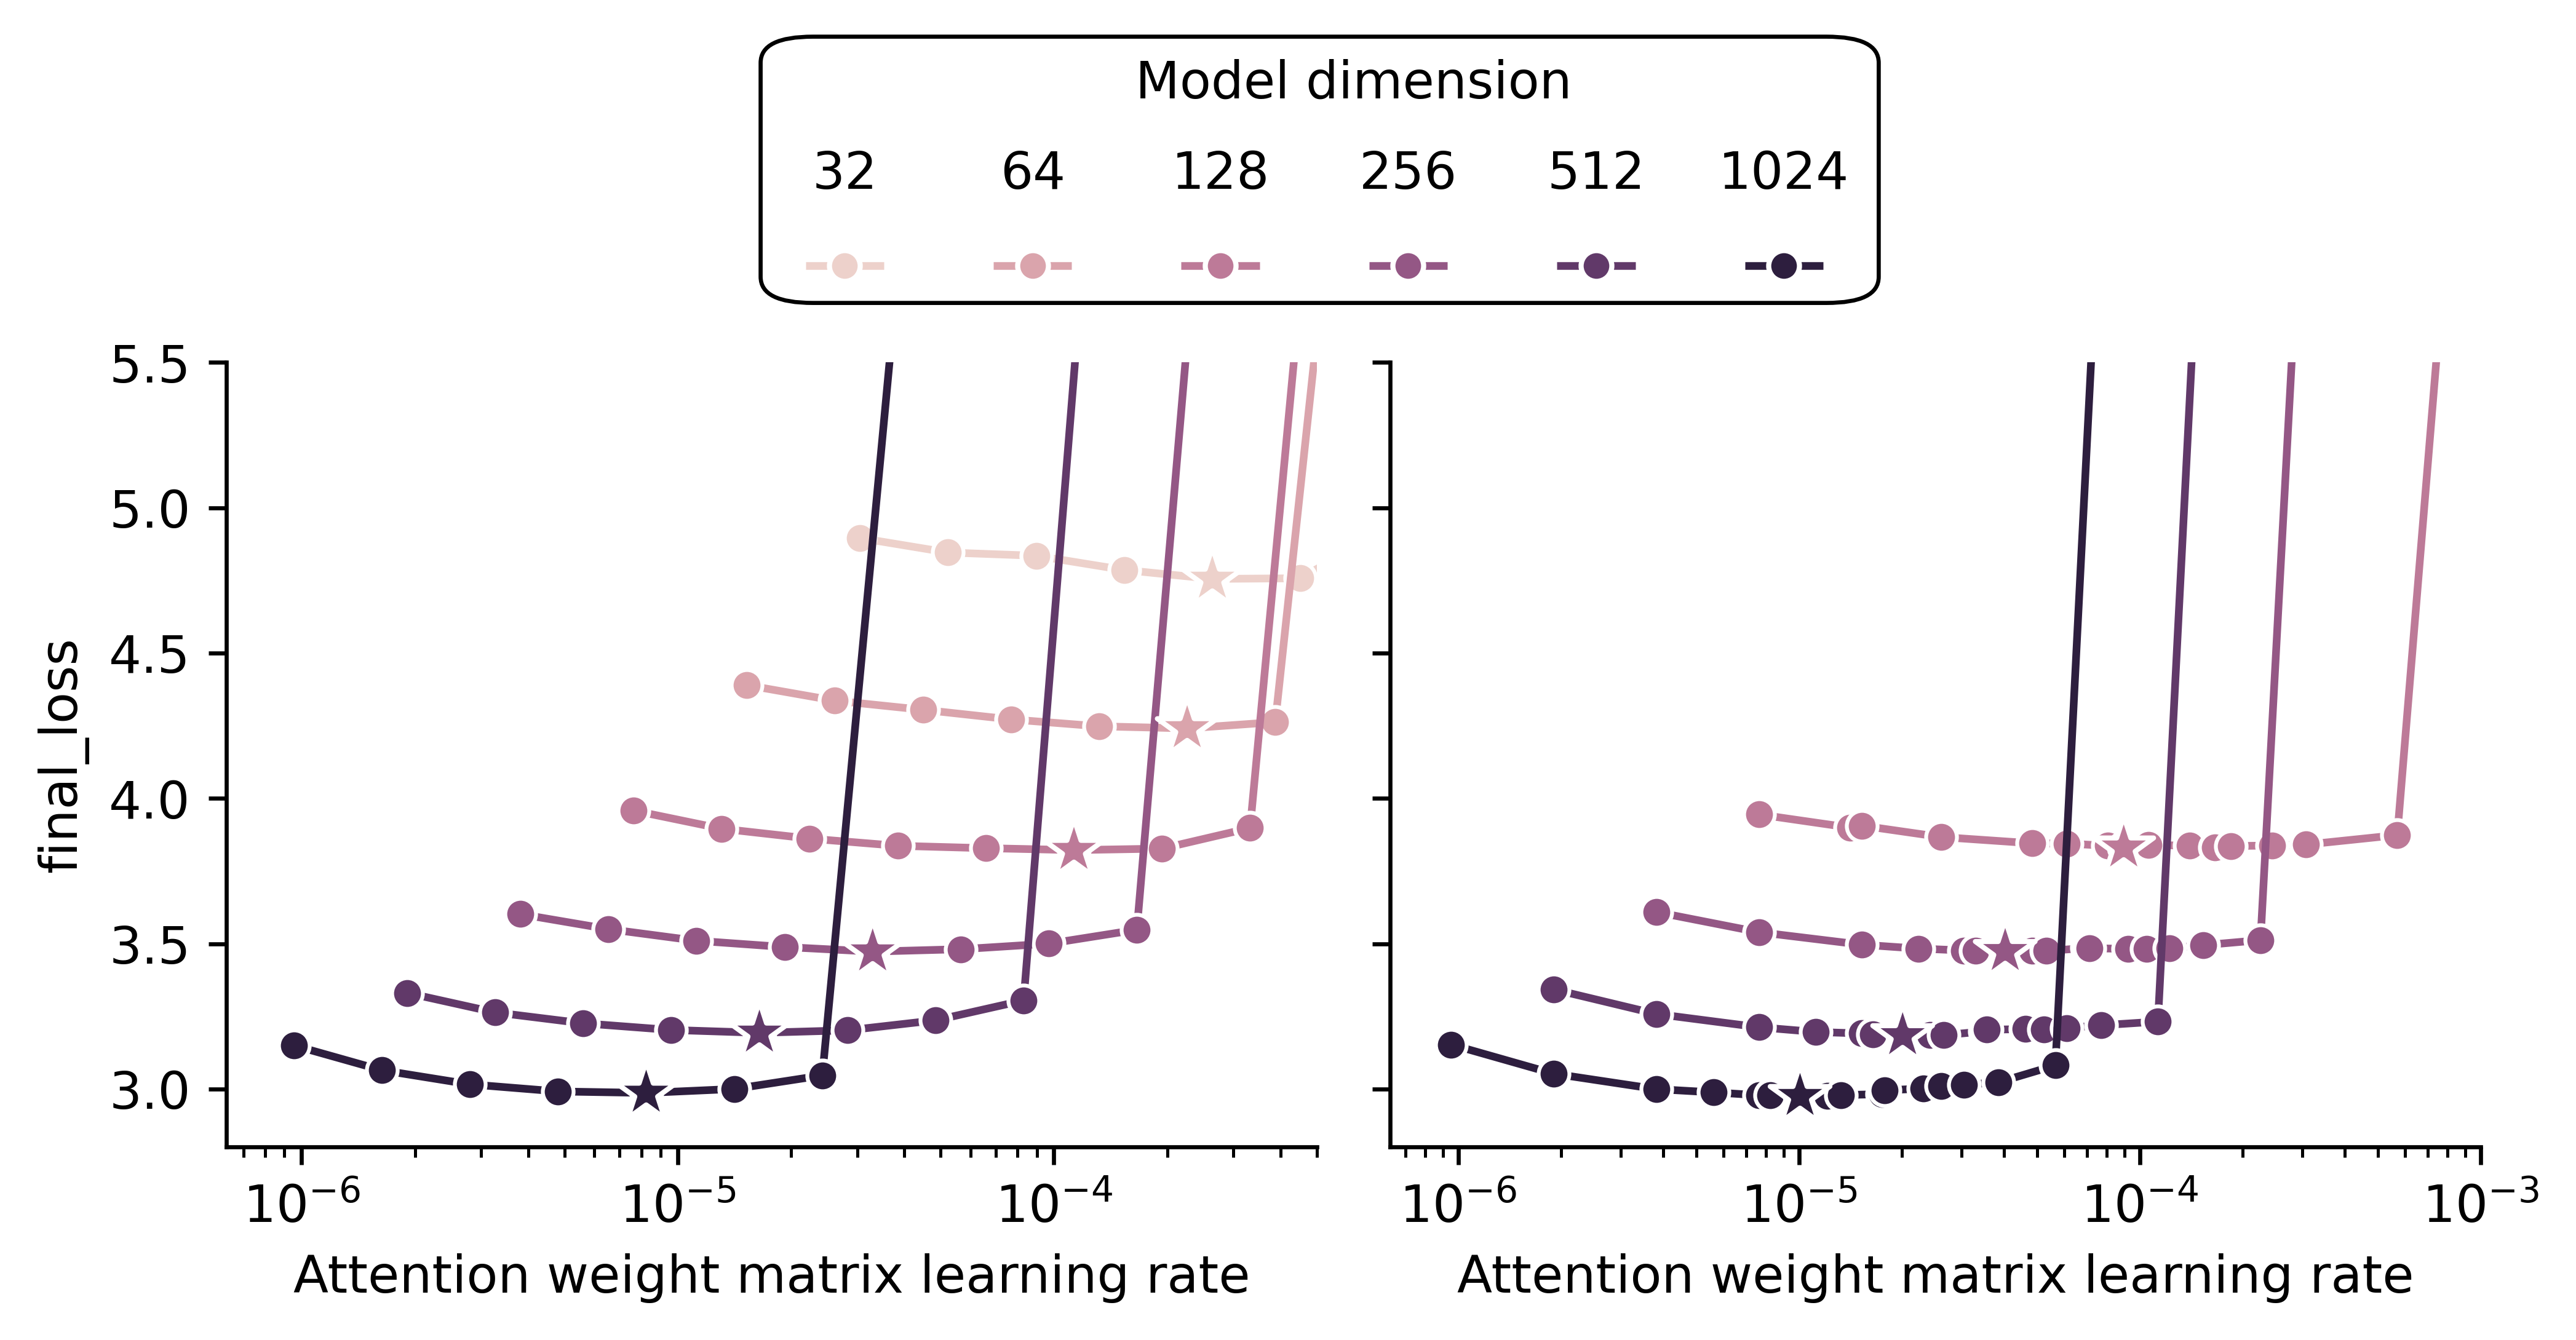

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(3.54 * 2, 3.54), sharey=True, dpi=600)

ax1, ax2 = axs

shared_norm = LogNorm(vmin=32, vmax=1024)

# final loss
plot1 = sns.lineplot(df_32_best_runs_not_relative.query('full_length_training == True'),
    x="attention_weight_matrix_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='o',
    zorder=1,
    )

sns.scatterplot(
    df_32_optimal_lrs_not_relative.query('full_length_training == True'),
    x='attention_weight_matrix_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

plot2 = sns.lineplot(df_128_best_runs_not_relative.query('full_length_training == True'),
    x="attention_weight_matrix_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='o',
    zorder=1,
    legend=False,
    )

sns.scatterplot(
    df_128_optimal_lrs_not_relative.query('full_length_training == True'),
    x='attention_weight_matrix_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax1.set_xscale('log', base=10)
ax1.set_xlim(10**-6.2, 0.0005)
ax1.set_ylim(2.8, 5.5)


ax2.set_xscale('log', base=10)
ax2.set_xlim(10**-6.2, 10**-3)
# ax1.set_ylabel('Loss')
ax1.set_xlabel('Attention weight matrix learning rate')
ax2.set_xlabel('Attention weight matrix learning rate')


# fig.subplots_adjust(top=0.8)  # leave room above the axes
fig.tight_layout(rect=[0, 0, 1, 0.82])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()



sns.despine()
# plt.tight_layout()
plt.show()

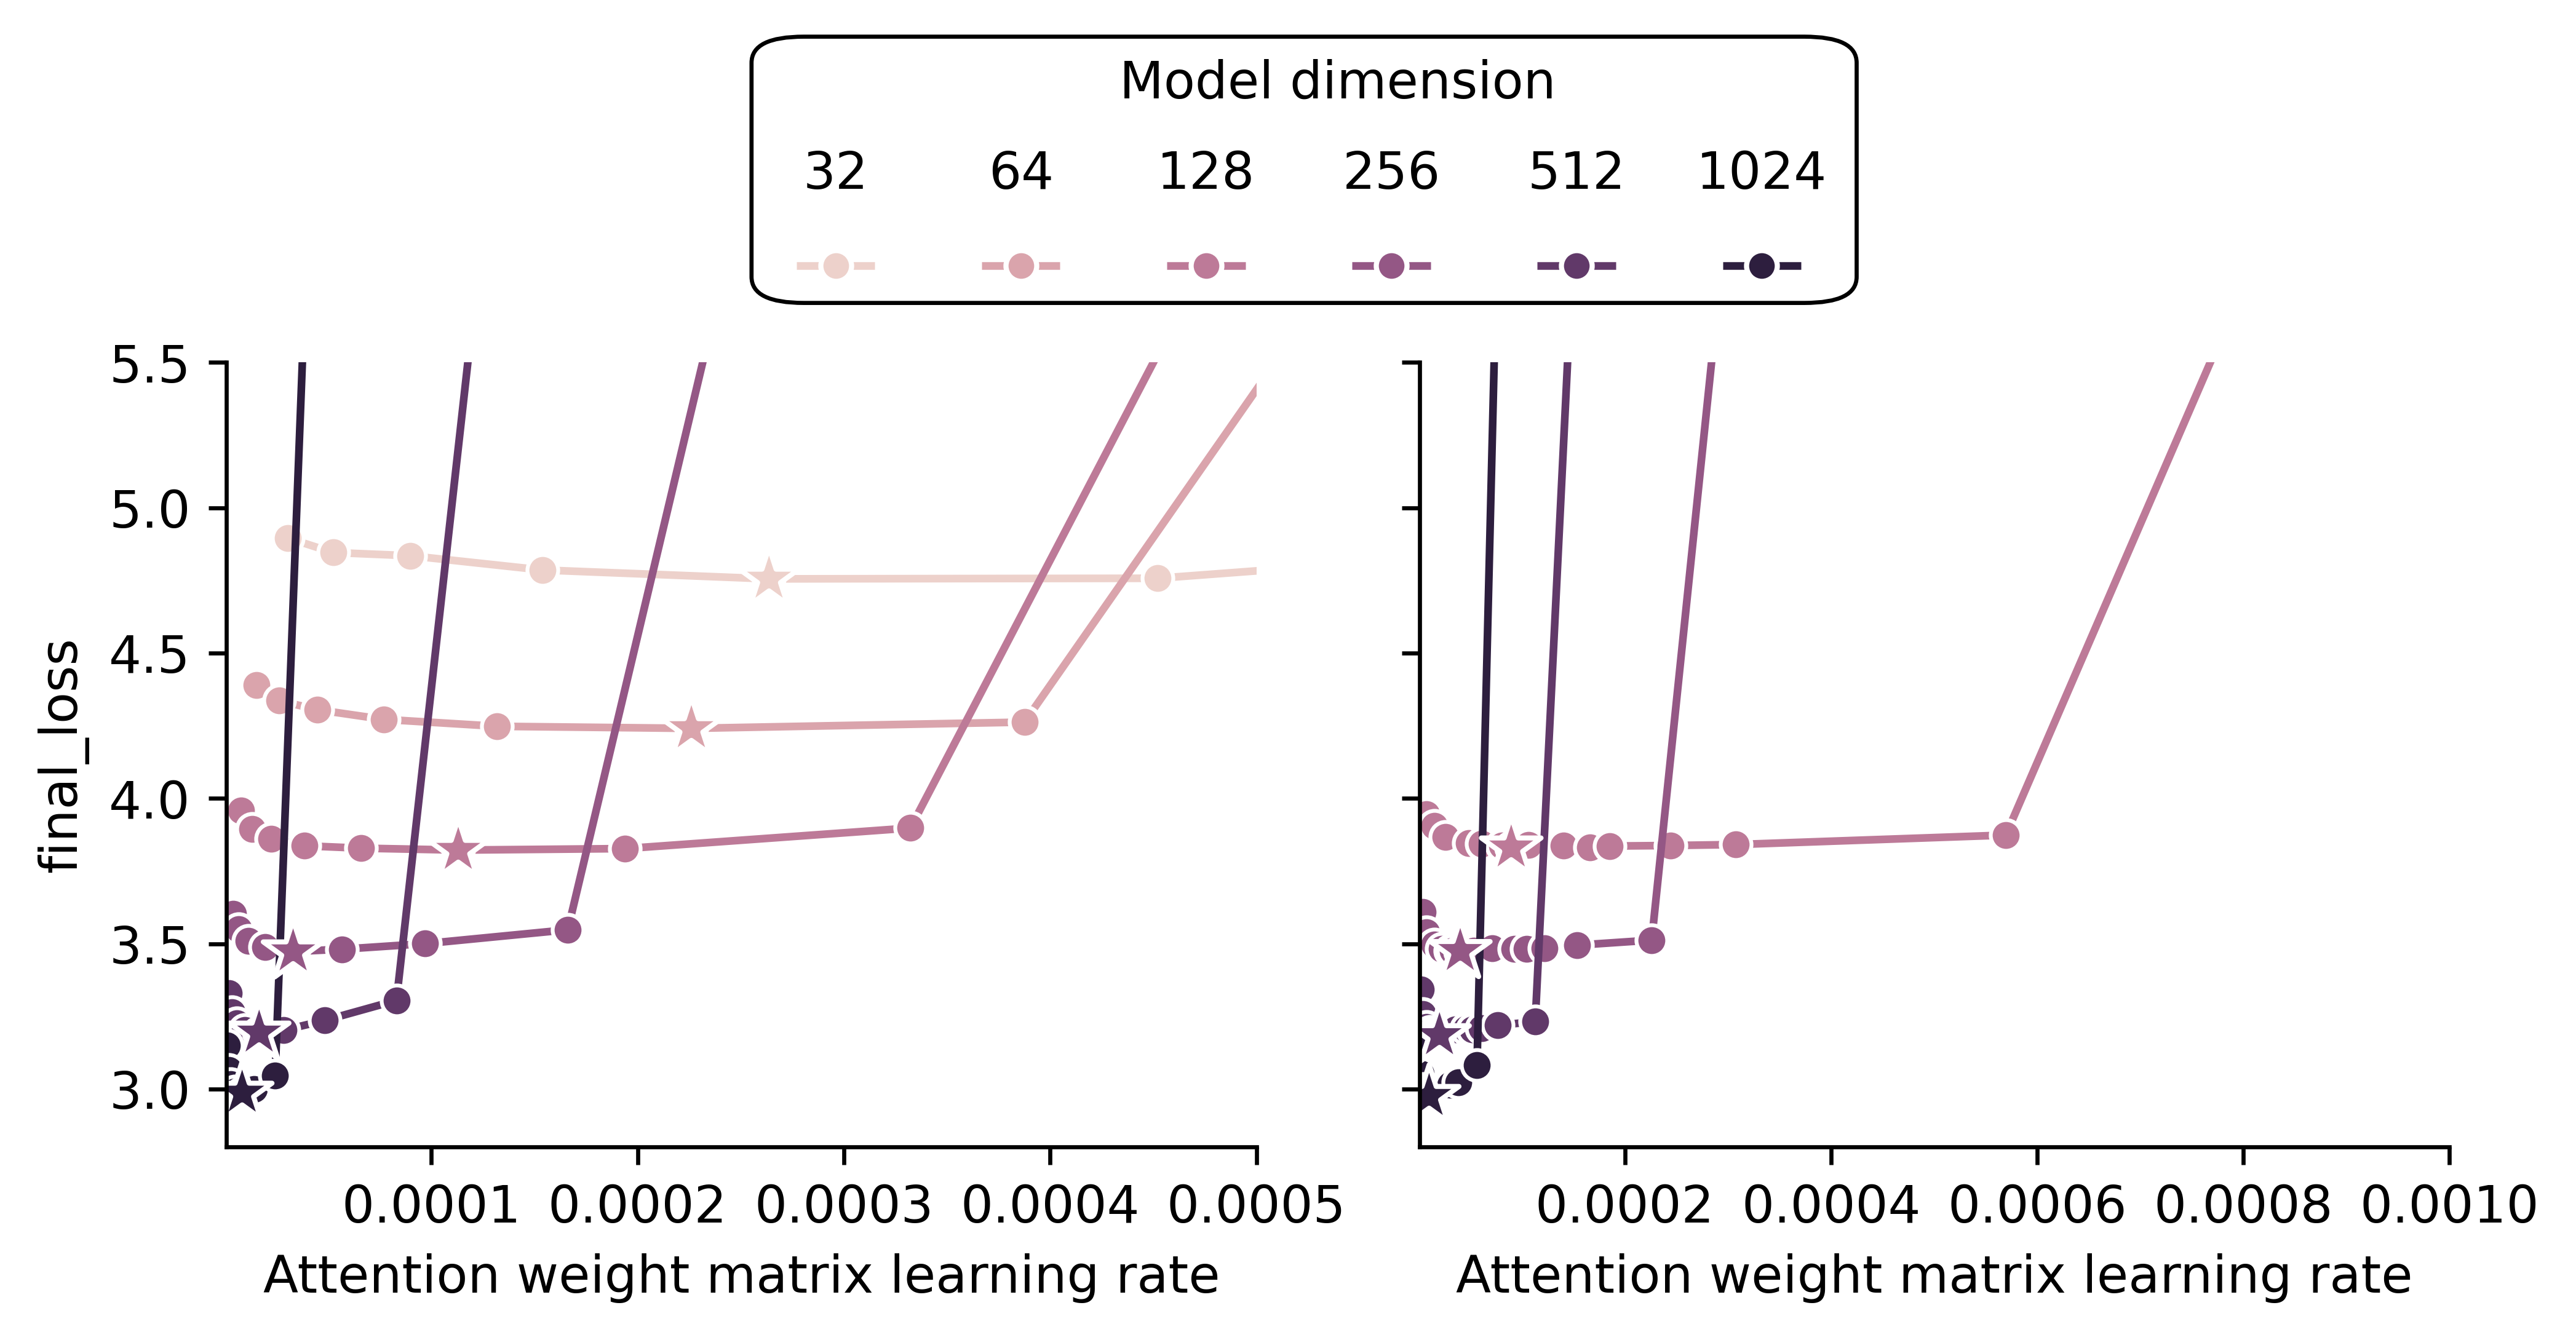

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(3.54 * 2, 3.54), sharey=True, dpi=600)

ax1, ax2 = axs

shared_norm = LogNorm(vmin=32, vmax=1024)

# final loss
plot1 = sns.lineplot(df_32_best_runs_not_relative.query('full_length_training == True'),
    x="attention_weight_matrix_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='o',
    zorder=1,
    )

sns.scatterplot(
    df_32_optimal_lrs_not_relative.query('full_length_training == True'),
    x='attention_weight_matrix_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

plot2 = sns.lineplot(df_128_best_runs_not_relative.query('full_length_training == True'),
    x="attention_weight_matrix_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='o',
    zorder=1,
    legend=False,
    )

sns.scatterplot(
    df_128_optimal_lrs_not_relative.query('full_length_training == True'),
    x='attention_weight_matrix_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=2,
)

ax1.set_xlim(10**-6.2, 0.0005)
ax1.set_ylim(2.8, 5.5)


ax2.set_xlim(10**-6.2, 10**-3)
# ax1.set_ylabel('Loss')
ax1.set_xlabel('Attention weight matrix learning rate')
ax2.set_xlabel('Attention weight matrix learning rate')


# fig.subplots_adjust(top=0.8)  # leave room above the axes
fig.tight_layout(rect=[0, 0, 1, 0.82])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()



sns.despine()
# plt.tight_layout()
plt.show()

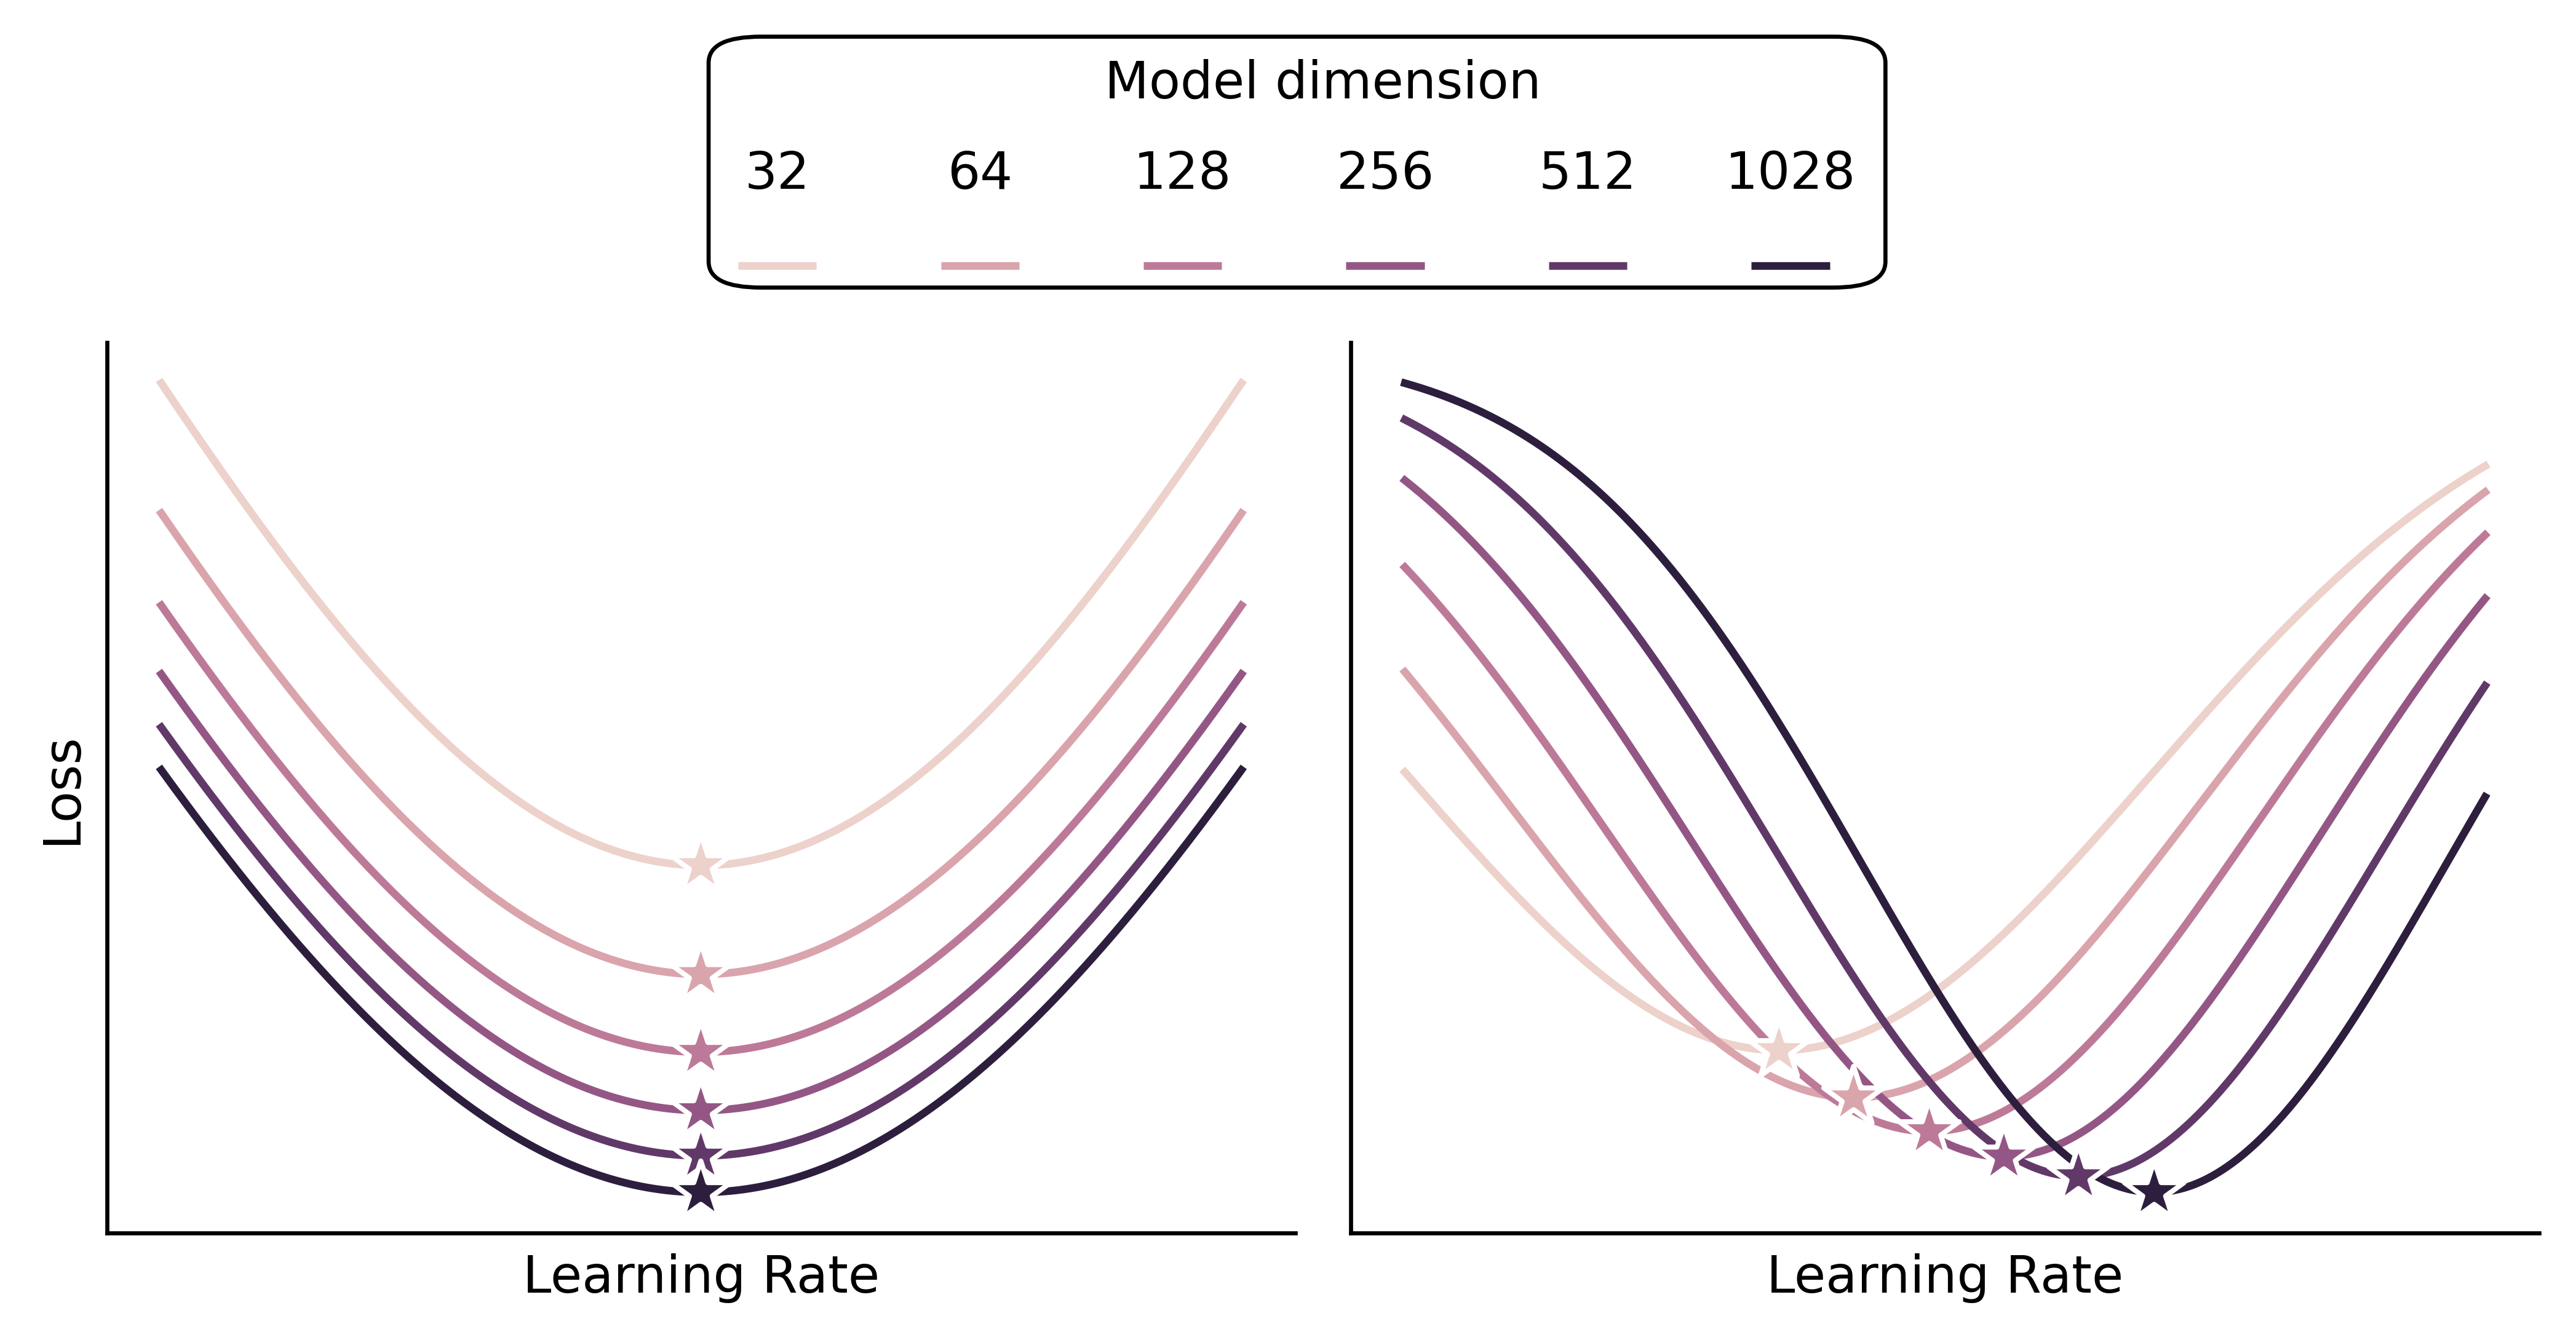

In [23]:

def inverted_gaussian(x, mu=0, sigma=1, amplitude=1, offset=0):
    """
    Upside-down Gaussian: a minimum at x=mu, tails rising on both sides.
    
    mu       : location of the minimum (mean)
    sigma    : controls the width (like standard deviation)
    amplitude: controls the depth of the dip
    offset   : baseline value the tails approach
    """
    return offset - amplitude * np.exp(-((x - mu)**2) / (2 * sigma**2))


shared_norm = LogNorm(vmin=32, vmax=1024)

d_models = [32, 64, 128, 256, 512, 1028]
xs = np.linspace(-3, 3, 1000)

dfs = []

for d_model in d_models:
    ys = inverted_gaussian(xs, sigma=5 - 5/np.log(d_model), amplitude=5 - 5/(np.log(d_model)), offset=0)
    dfs.append(pd.DataFrame({'x': xs, 'y': ys, 'd_model': d_model}))

df1 = pd.concat(dfs, ignore_index=True)

idx = df1.groupby('d_model')['y'].idxmin()
df1_minima = df1.loc[idx, ['d_model', 'x', 'y']]

# ===========================================================
# not working case


xs = np.linspace(0, 10, 1000)
dfs = []

for d_model in d_models:
    ys = inverted_gaussian(xs, mu=np.log(d_model), sigma=2 + 5/np.log(d_model), amplitude=1 - 1/(np.log(d_model)), offset=0)
    dfs.append(pd.DataFrame({'x': xs, 'y': ys, 'd_model': d_model}))

df2 = pd.concat(dfs, ignore_index=True)

idx = df2.groupby('d_model')['y'].idxmin()
df2_minima = df2.loc[idx, ['d_model', 'x', 'y']]

fig, axs = plt.subplots(1, 2, figsize=(3.54 * 2, 3.54), sharey=False, dpi=600)

ax1, ax2 = axs


# final loss
sns.lineplot(df1,
    x='x',
    y='y',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker=None,
    zorder=1,
    linewidth=1.5,
    )

sns.scatterplot(df1_minima,
    x='x',
    y='y',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='*',
    s=150,
    zorder=2,
    legend=None,
)

sns.lineplot(df2,
    x='x',
    y='y',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker=None,
    zorder=1,
    legend=None,
    )

sns.scatterplot(df2_minima,
    x='x',
    y='y',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='*',
    s=150,
    zorder=2,
    legend=None,
)


ax1.set_xticklabels([])
ax1.set_xticks([])
ax1.set_yticklabels([])
ax1.set_yticks([])
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Loss')

ax2.set_xticklabels([])
ax2.set_xticks([])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('')



# fig.subplots_adjust(top=0.8)  # leave room above the axes
fig.tight_layout(rect=[0, 0, 1, 0.82])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()


sns.despine()
# plt.tight_layout()
plt.show()

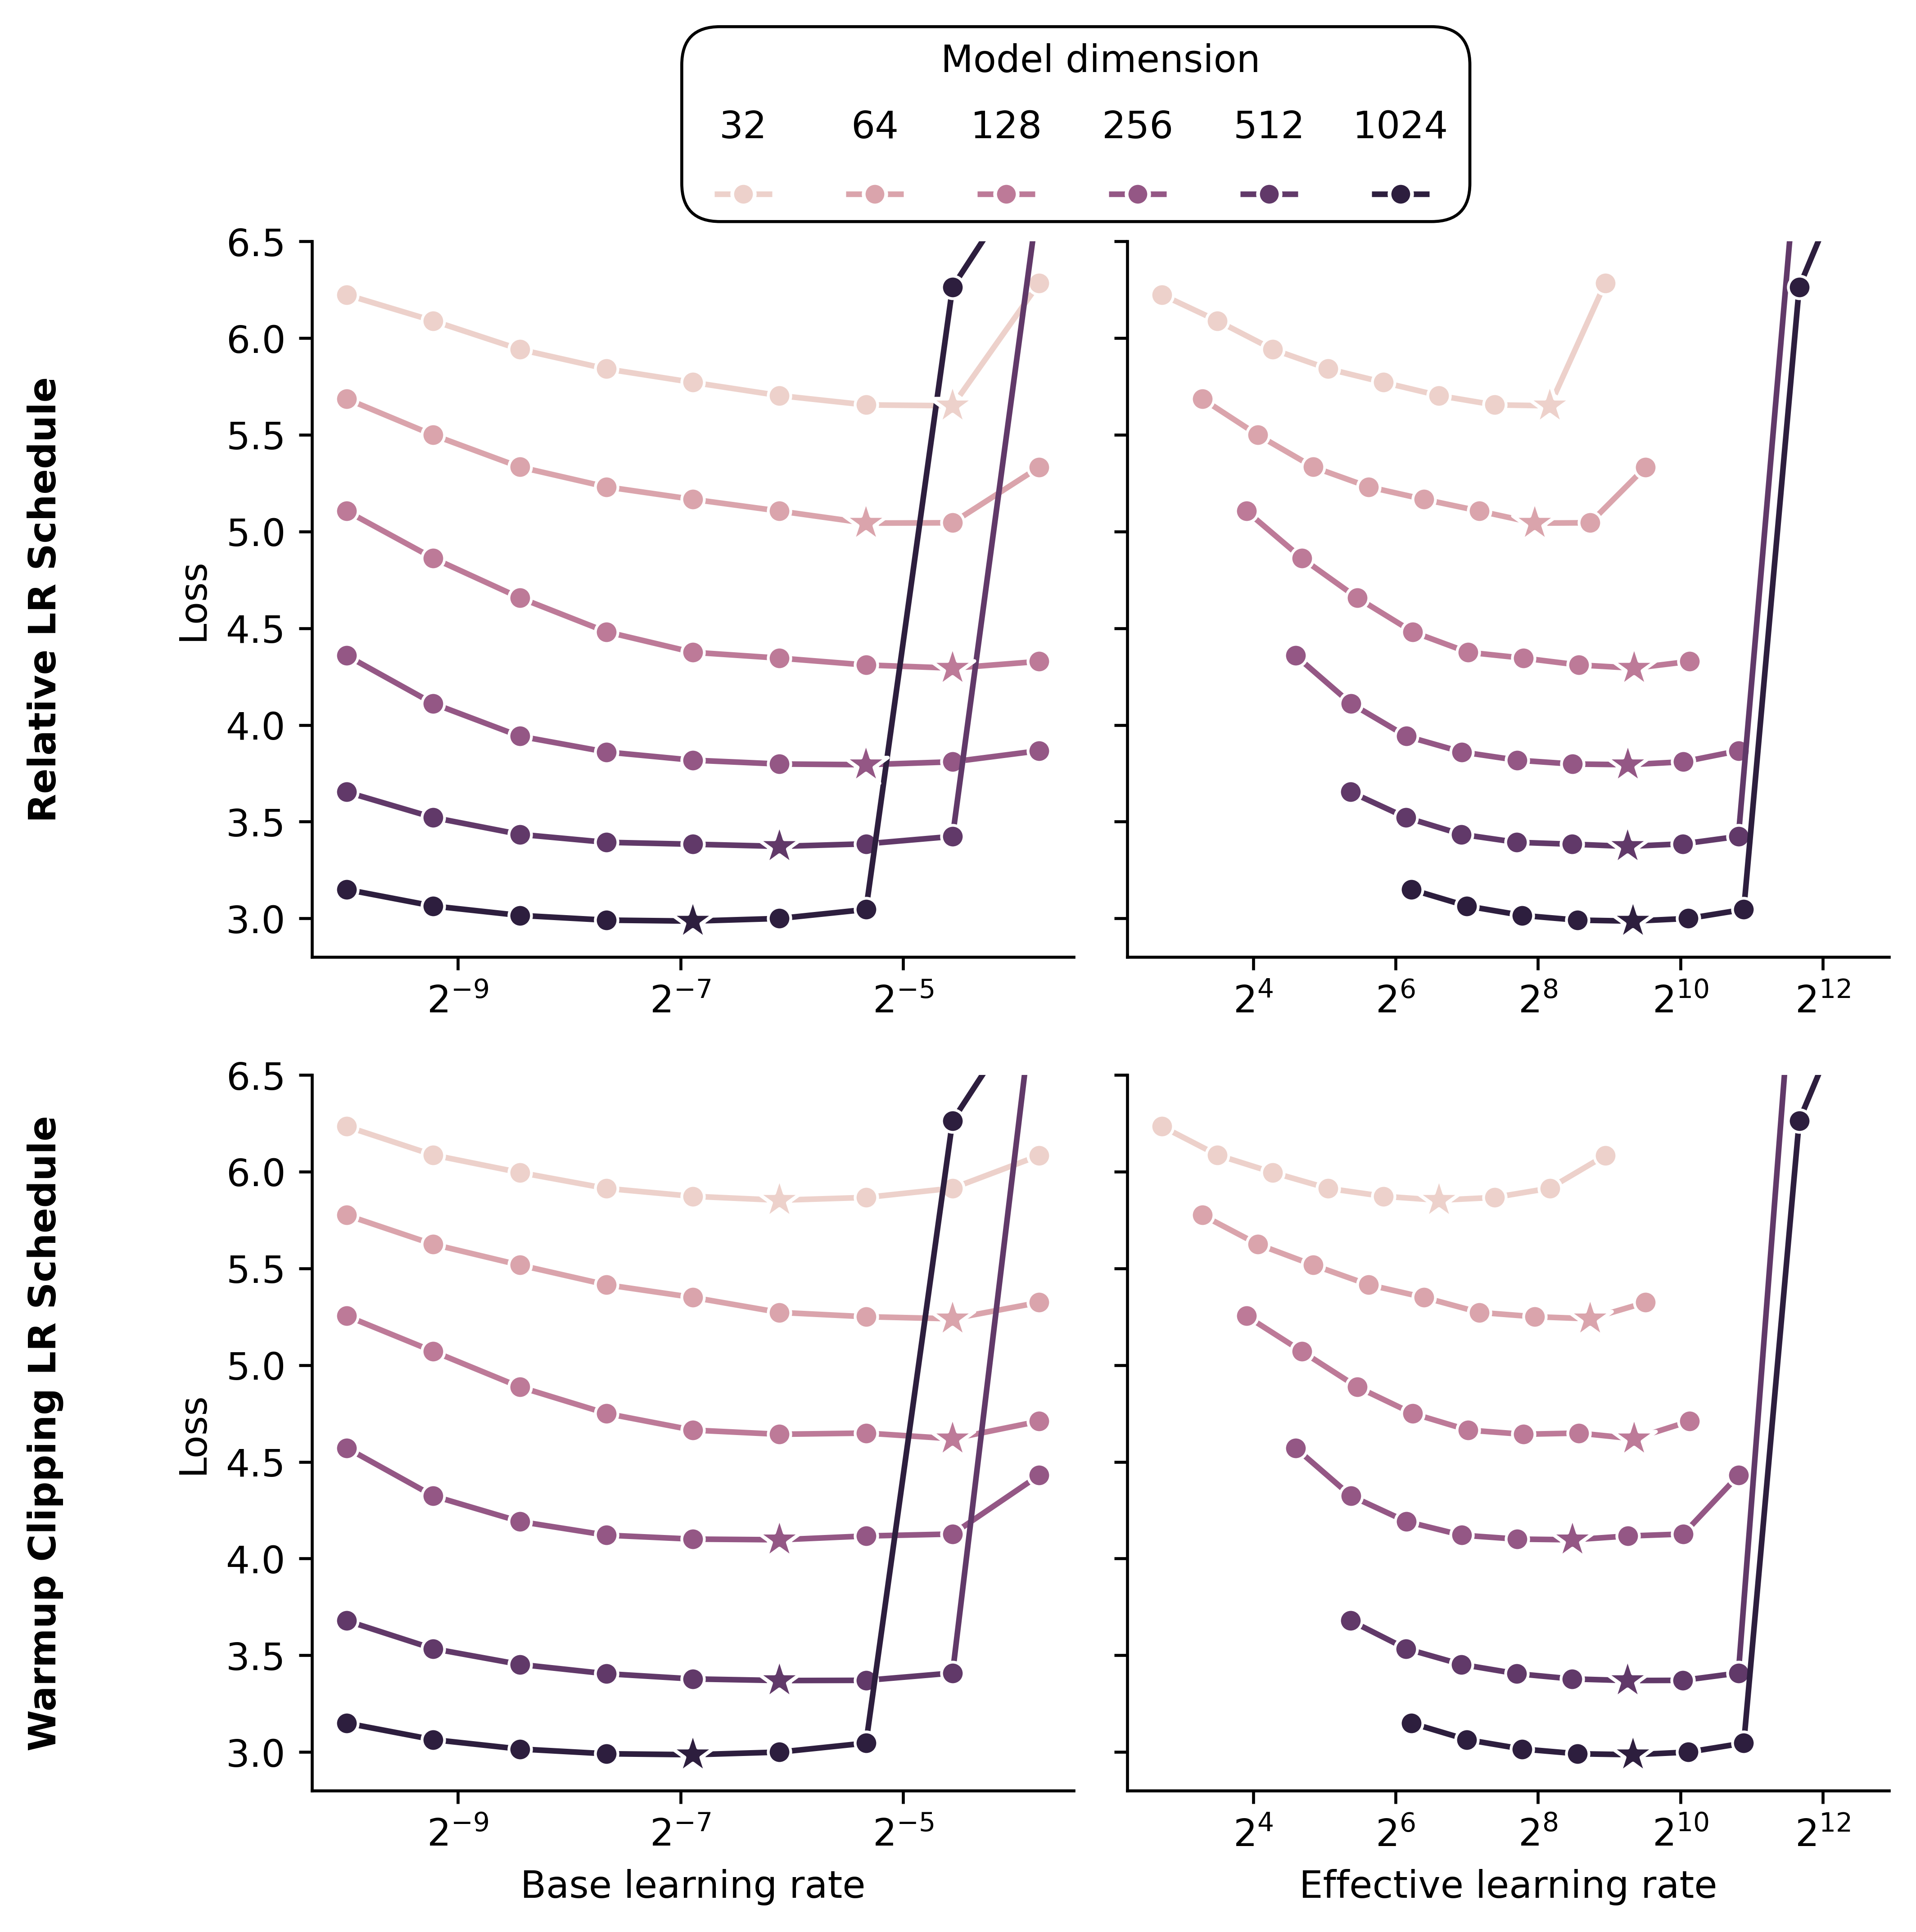

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(2*3.54, 2*3.54), sharey=True, dpi=600)

ax1, ax2, ax3, ax4 = axs.flatten()

relative_merged_run_df_32 = pd.concat(
    [
        df_32_best_runs_not_relative.query("d_model == 1024"),
        df_32_best_runs_relative
    ]
)
relative_merged_optimal_lr_df_32 = pd.concat([
    df_32_optimal_lrs_not_relative.query('d_model == 1024'),
    df_32_optimal_lrs_relative
])

clipping_merged_run_df_32 = pd.concat(
    [
        df_32_best_runs_not_relative.query("d_model == 1024"),
        df_32_best_runs_not_relative.query("full_length_training == False")
    ]
)
clipping_merged_optimal_lr_df_32 = pd.concat([
    df_32_optimal_lrs_not_relative.query('d_model == 1024'),
    df_32_optimal_lrs_not_relative.query("full_length_training == False")
])

# merged_run_df_128 = pd.concat(
#     [
#         df_best_runs_not_relative.query("d_model == 1024"),
#         df_best_runs_relative
#     ]
# )
# merged_optimal_lr_df_128 = pd.concat([
#     df_optimal_lrs_not_relative.query('d_model == 1024'),
#     df_optimal_lrs_relative
# ])
shared_norm = LogNorm(vmin=32, vmax=1024)

# final loss
sns.lineplot(relative_merged_run_df_32,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    relative_merged_optimal_lr_df_32,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax1.set_xscale('log', base=2)
# ax.set_xlim(2**-10.2, 2**-3.55)
ax1.set_ylim(2.8, 6.5)

# labels
ax1.set_xlabel('')
ax1.set_ylabel('Loss')



# effective lr
sns.lineplot(relative_merged_run_df_32,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='o',
    zorder=2,
    legend=False,
    )

sns.scatterplot(
    relative_merged_optimal_lr_df_32,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax2.set_xscale('log', base=2)
# ax.set_xlim(2**-10.2, 2**-3.55)
# ax2.set_ylim(2.8, 6.5)

# labels
ax2.set_xlabel('')
# ax2.set_ylabel('Loss')



# clipping
sns.lineplot(clipping_merged_run_df_32,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax3,
    marker='o',
    zorder=2,
    legend=False
    )

sns.scatterplot(
    clipping_merged_optimal_lr_df_32,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax3,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax3.set_xscale('log', base=2)
# ax.set_xlim(2**-10.2, 2**-3.55)
ax3.set_ylim(2.8, 6.5)

# labels
ax3.set_xlabel('Base learning rate')
ax3.set_ylabel('Loss')



# effective lr
sns.lineplot(clipping_merged_run_df_32,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax4,
    marker='o',
    zorder=2,
    legend=False,
    )

sns.scatterplot(
    clipping_merged_optimal_lr_df_32,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax4,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax4.set_xscale('log', base=2)
# ax4.set_xlim(2**2.8, 2**11.2)
# ax3.set_ylim(2.8, 6.5)

# labels
ax4.set_xlabel('Effective learning rate')
# ax3.set_ylabel('Loss')


# add row labes
add_row_label(ax1, 'Relative LR Schedule')
add_row_label(ax3, 'Warmup Clipping LR Schedule')


# legend
# fig.subplots_adjust(top=0.8)  # leave room above the axes
fig.tight_layout(rect=[0, 0, 1, 0.92])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2, ax3, ax4], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()

# ax.set_title("Loss vs optimal learning rate under muTransfer with relative lr schedule")
sns.despine()

# plt.tight_layout()
plt.show()

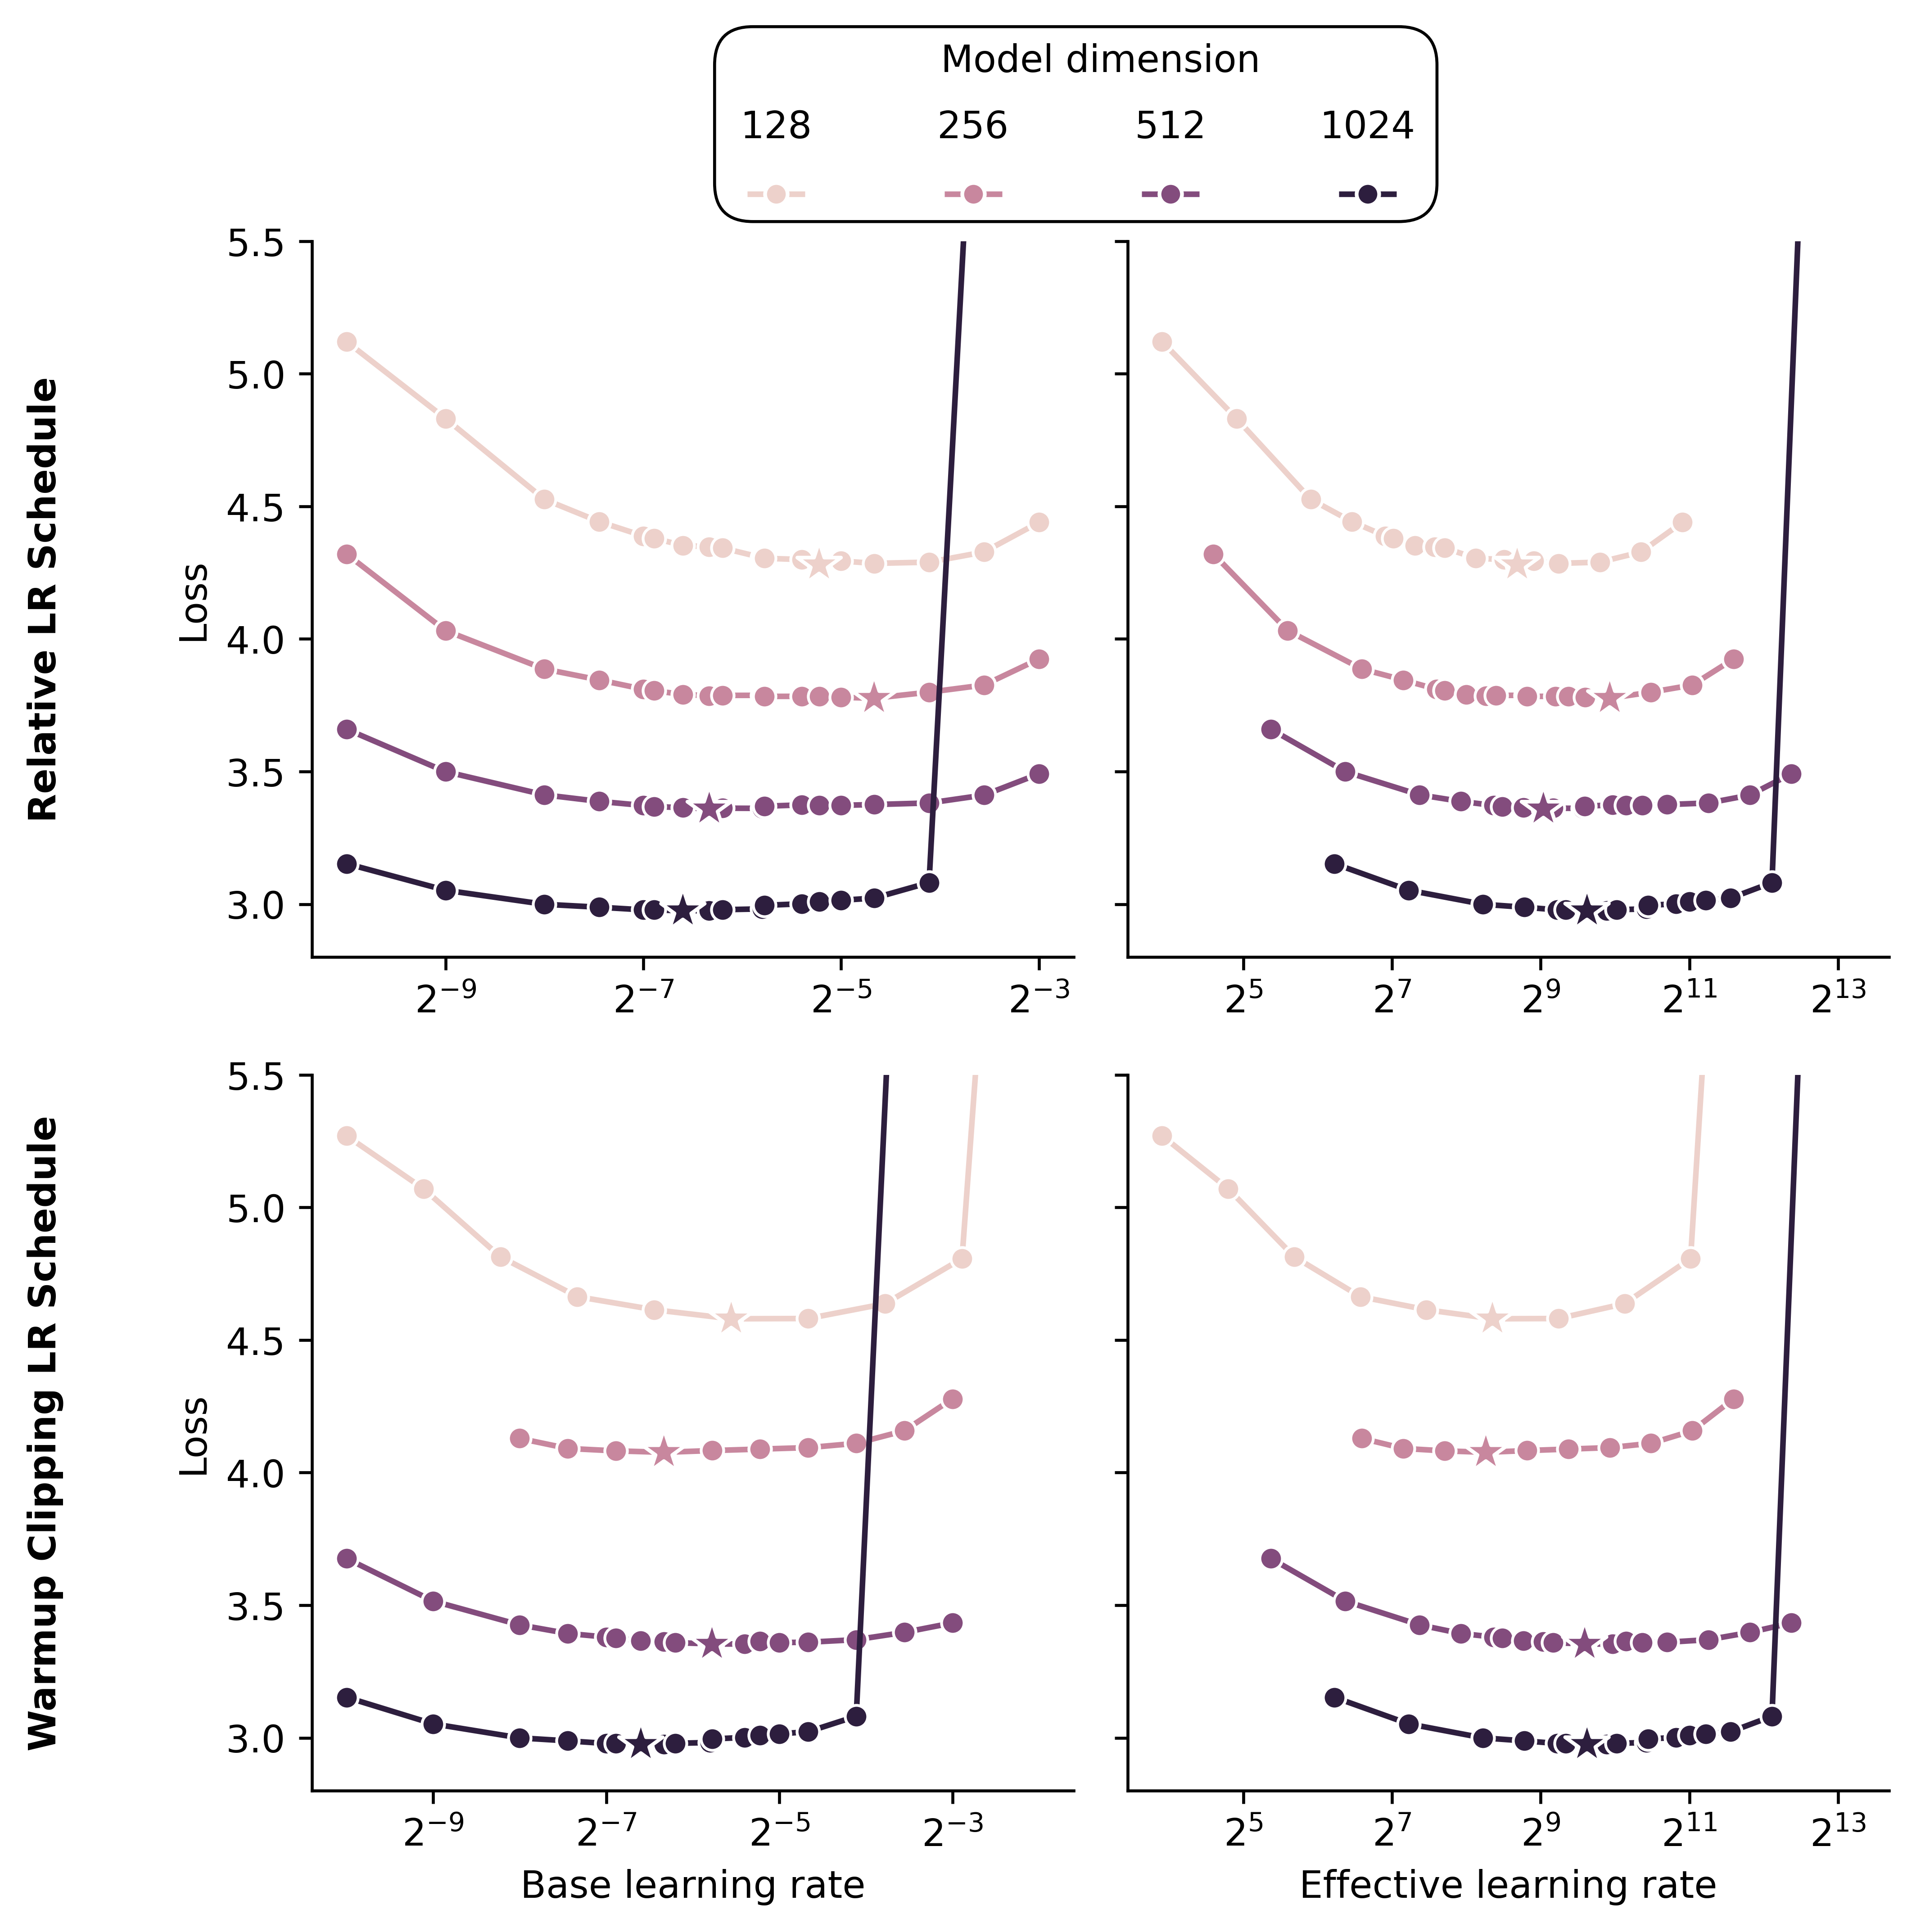

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(2*3.54, 2*3.54), sharey=True, dpi=600)

ax1, ax2, ax3, ax4 = axs.flatten()

relative_merged_run_df_128 = pd.concat(
    [
        df_128_best_runs_not_relative.query("d_model == 1024"),
        df_128_best_runs_relative
    ]
)
relative_merged_optimal_lr_df_128 = pd.concat([
    df_128_optimal_lrs_not_relative.query('d_model == 1024'),
    df_128_optimal_lrs_relative
])

clipping_merged_run_df_128 = pd.concat(
    [
        df_128_best_runs_not_relative.query("d_model == 1024"),
        df_128_best_runs_not_relative.query("full_length_training == False")
    ]
)
clipping_merged_optimal_lr_df_128 = pd.concat([
    df_128_optimal_lrs_not_relative.query('d_model == 1024'),
    df_128_optimal_lrs_not_relative.query("full_length_training == False")
])

# merged_run_df_128 = pd.concat(
#     [
#         df_best_runs_not_relative.query("d_model == 1024"),
#         df_best_runs_relative
#     ]
# )
# merged_optimal_lr_df_128 = pd.concat([
#     df_optimal_lrs_not_relative.query('d_model == 1024'),
#     df_optimal_lrs_relative
# ])
shared_norm = LogNorm(vmin=128, vmax=1024)

# final loss
sns.lineplot(relative_merged_run_df_128,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    relative_merged_optimal_lr_df_128,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax1,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax1.set_xscale('log', base=2)
# ax.set_xlim(2**-10.2, 2**-3.55)
ax1.set_ylim(2.8, 5.5)

# labels
ax1.set_xlabel('')
ax1.set_ylabel('Loss')



# effective lr
sns.lineplot(relative_merged_run_df_128,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='o',
    zorder=2,
    legend=False,
    )

sns.scatterplot(
    relative_merged_optimal_lr_df_128,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax2,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax2.set_xscale('log', base=2)
# ax.set_xlim(2**-10.2, 2**-3.55)
# ax2.set_ylim(2.8, 6.5)

# labels
ax2.set_xlabel('')
# ax2.set_ylabel('Loss')



# clipping
sns.lineplot(clipping_merged_run_df_128,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax3,
    marker='o',
    zorder=2,
    legend=False
    )

sns.scatterplot(
    clipping_merged_optimal_lr_df_128,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax3,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax3.set_xscale('log', base=2)
# ax.set_xlim(2**-10.2, 2**-3.55)
ax3.set_ylim(2.8, 5.5)

# labels
ax3.set_xlabel('Base learning rate')
ax3.set_ylabel('Loss')



# effective lr
sns.lineplot(clipping_merged_run_df_128,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax4,
    marker='o',
    zorder=2,
    legend=False,
    )

sns.scatterplot(
    clipping_merged_optimal_lr_df_128,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=shared_norm,
    ax=ax4,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)

ax4.set_xscale('log', base=2)
# ax4.set_xlim(2**2.8, 2**11.2)
# ax3.set_ylim(2.8, 6.5)

# labels
ax4.set_xlabel('Effective learning rate')
# ax3.set_ylabel('Loss')


# add row labes
add_row_label(ax1, 'Relative LR Schedule')
add_row_label(ax3, 'Warmup Clipping LR Schedule')


# legend
# fig.subplots_adjust(top=0.8)  # leave room above the axes
fig.tight_layout(rect=[0, 0, 1, 0.92])   # reserve top ~14% for the legend
two_row_legend_fig(fig, [ax1, ax2, ax3, ax4], x_offset=-0.015, spread=0.5, title='Model dimension')

legend = ax1.legend()
legend.remove()

# ax.set_title("Loss vs optimal learning rate under muTransfer with relative lr schedule")
sns.despine()

# plt.tight_layout()
plt.show()

NameError: name 'df_best_runs_not_relative' is not defined

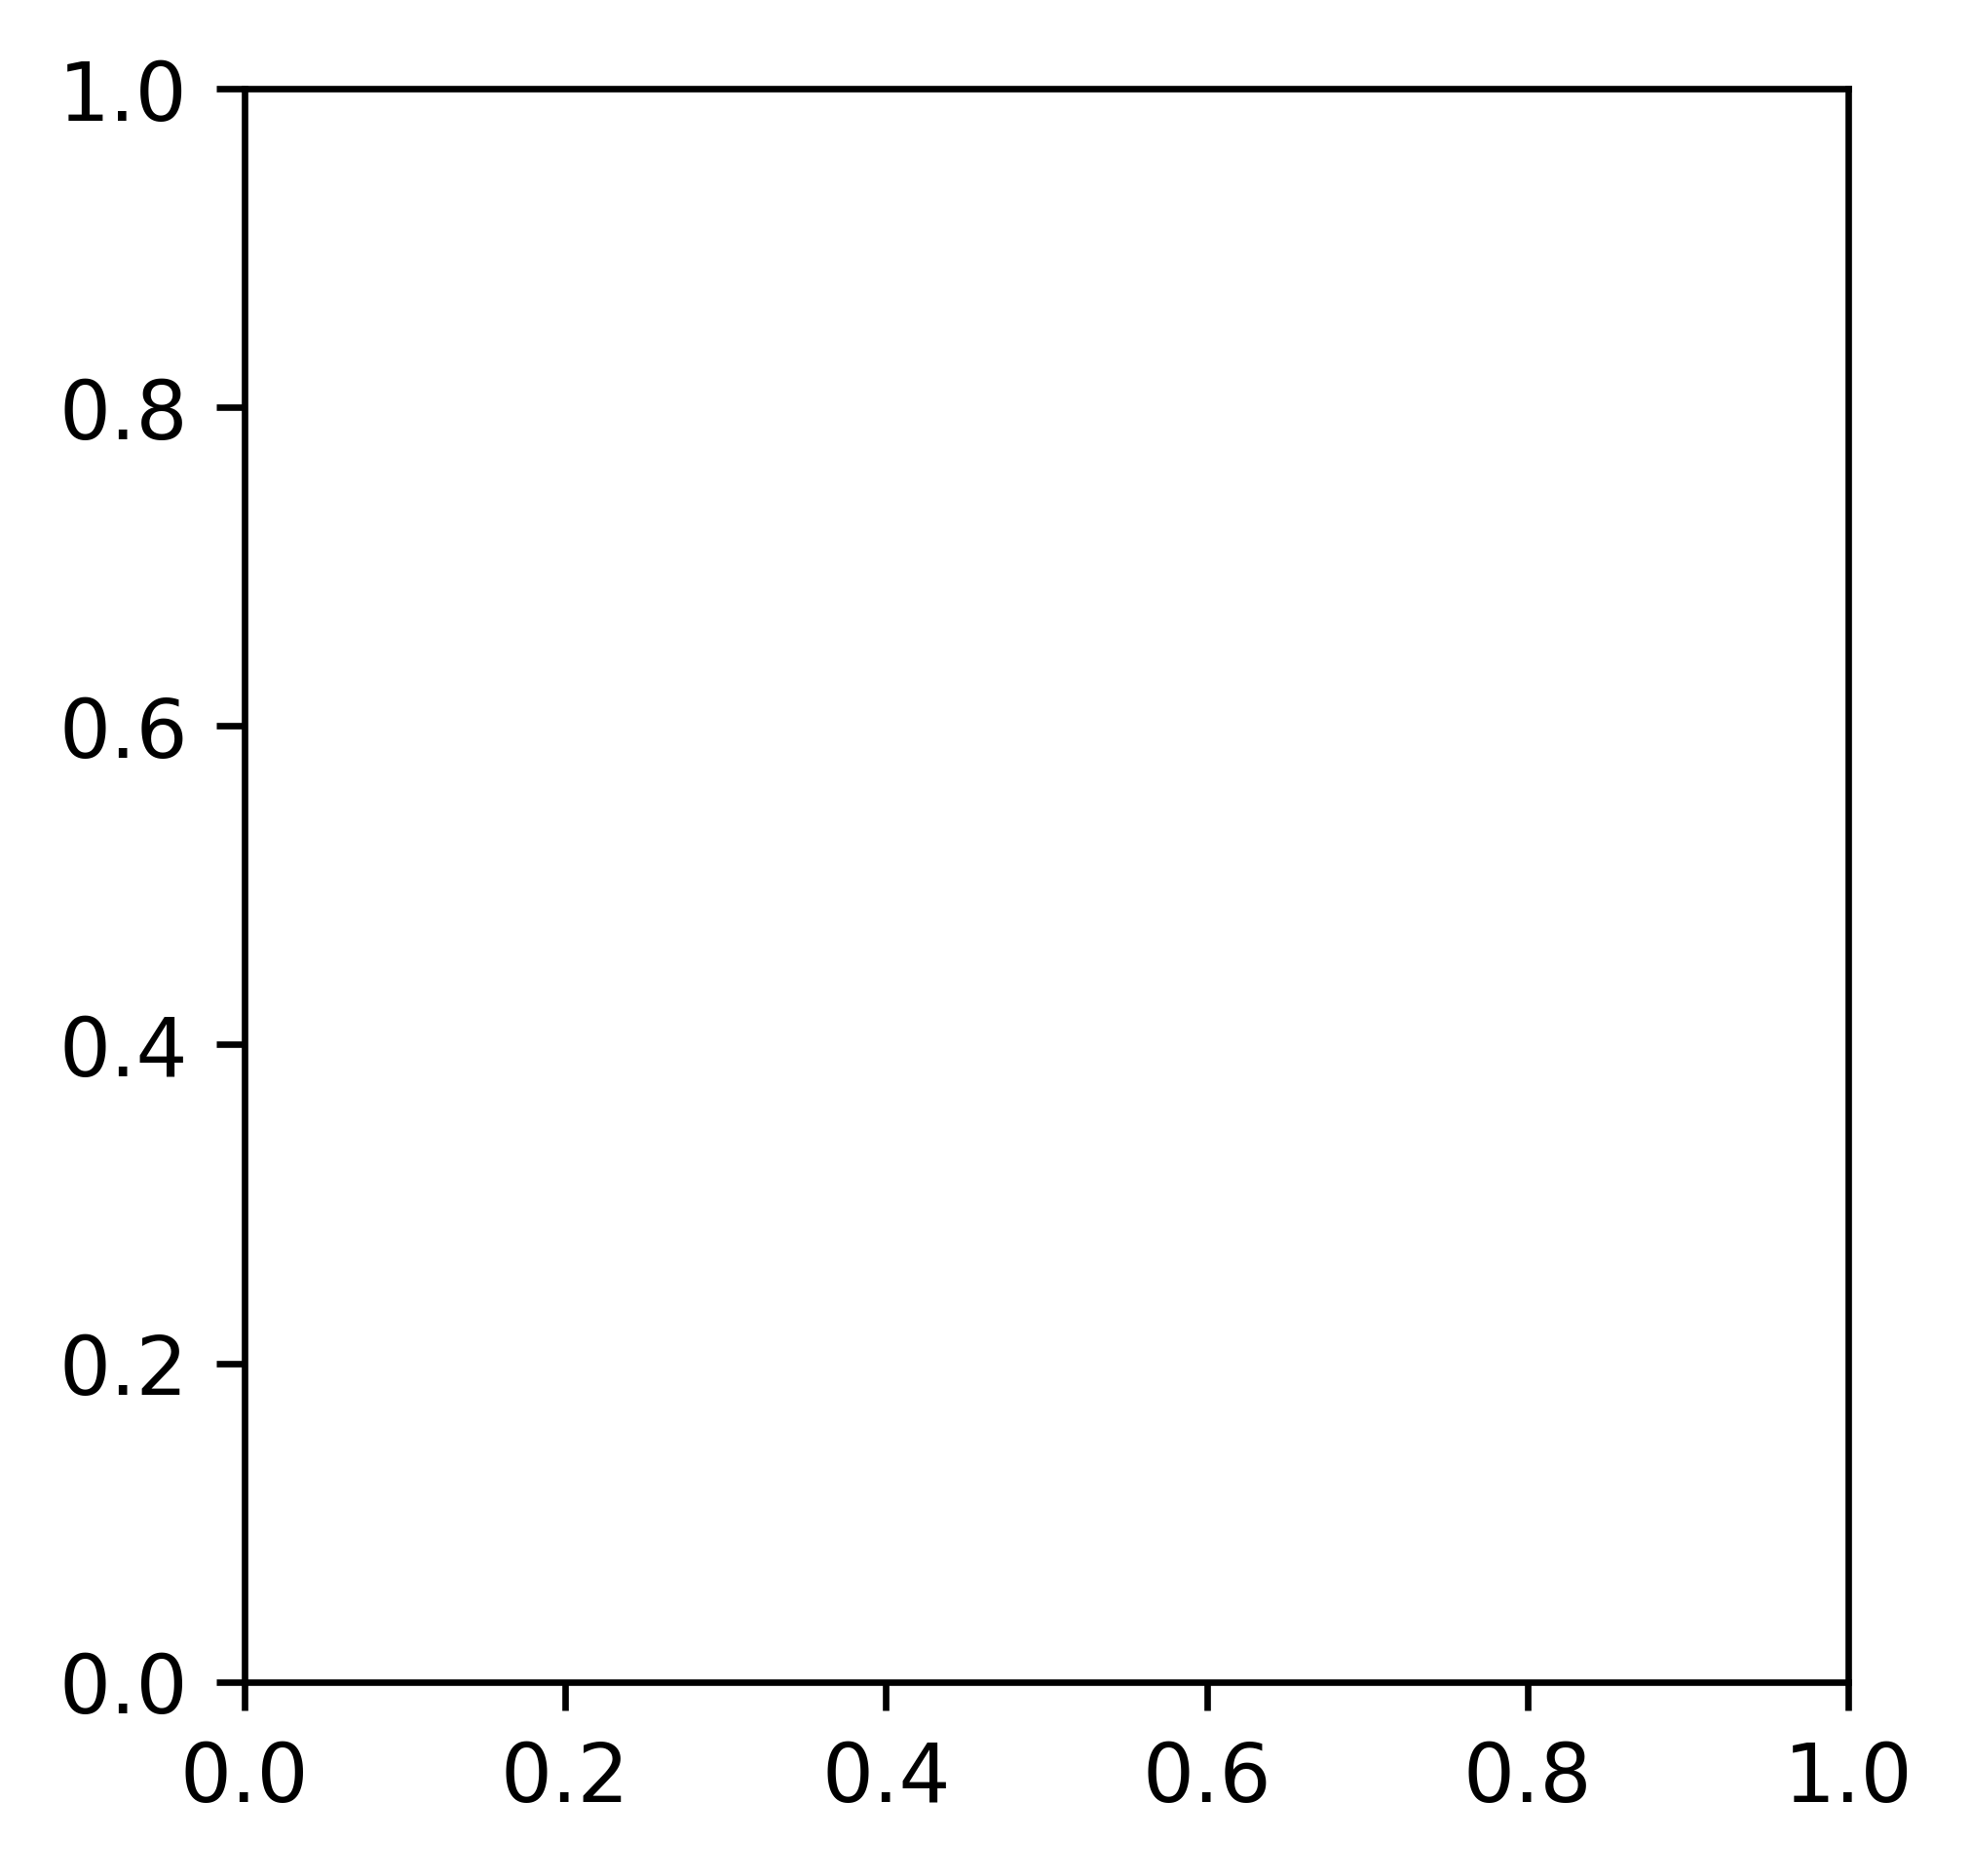

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

merged_run_df = pd.concat(
    [
        df_best_runs_not_relative.query("d_model == 1024"),
        df_best_runs_relative
    ]
)
merged_optimal_lr_df = pd.concat([
    df_optimal_lrs_not_relative.query('d_model == 1024'),
    df_optimal_lrs_relative
])

# final loss
sns.lineplot(merged_run_df,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    merged_optimal_lr_df,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)



ax.set_xscale('log', base=2)
ax.set_xlim(2**2.35, 2**11.5)
ax.set_ylim(2.8, 6.5)

# labels
ax.set_xlabel('effective learning rate')
ax.set_ylabel('loss')

# legend
two_row_legend(ax, x_offset=-0.015)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

# ax.set_title("Loss vs optimal learning rate under muTransfer with relative lr schedule")

plt.tight_layout()
plt.show()

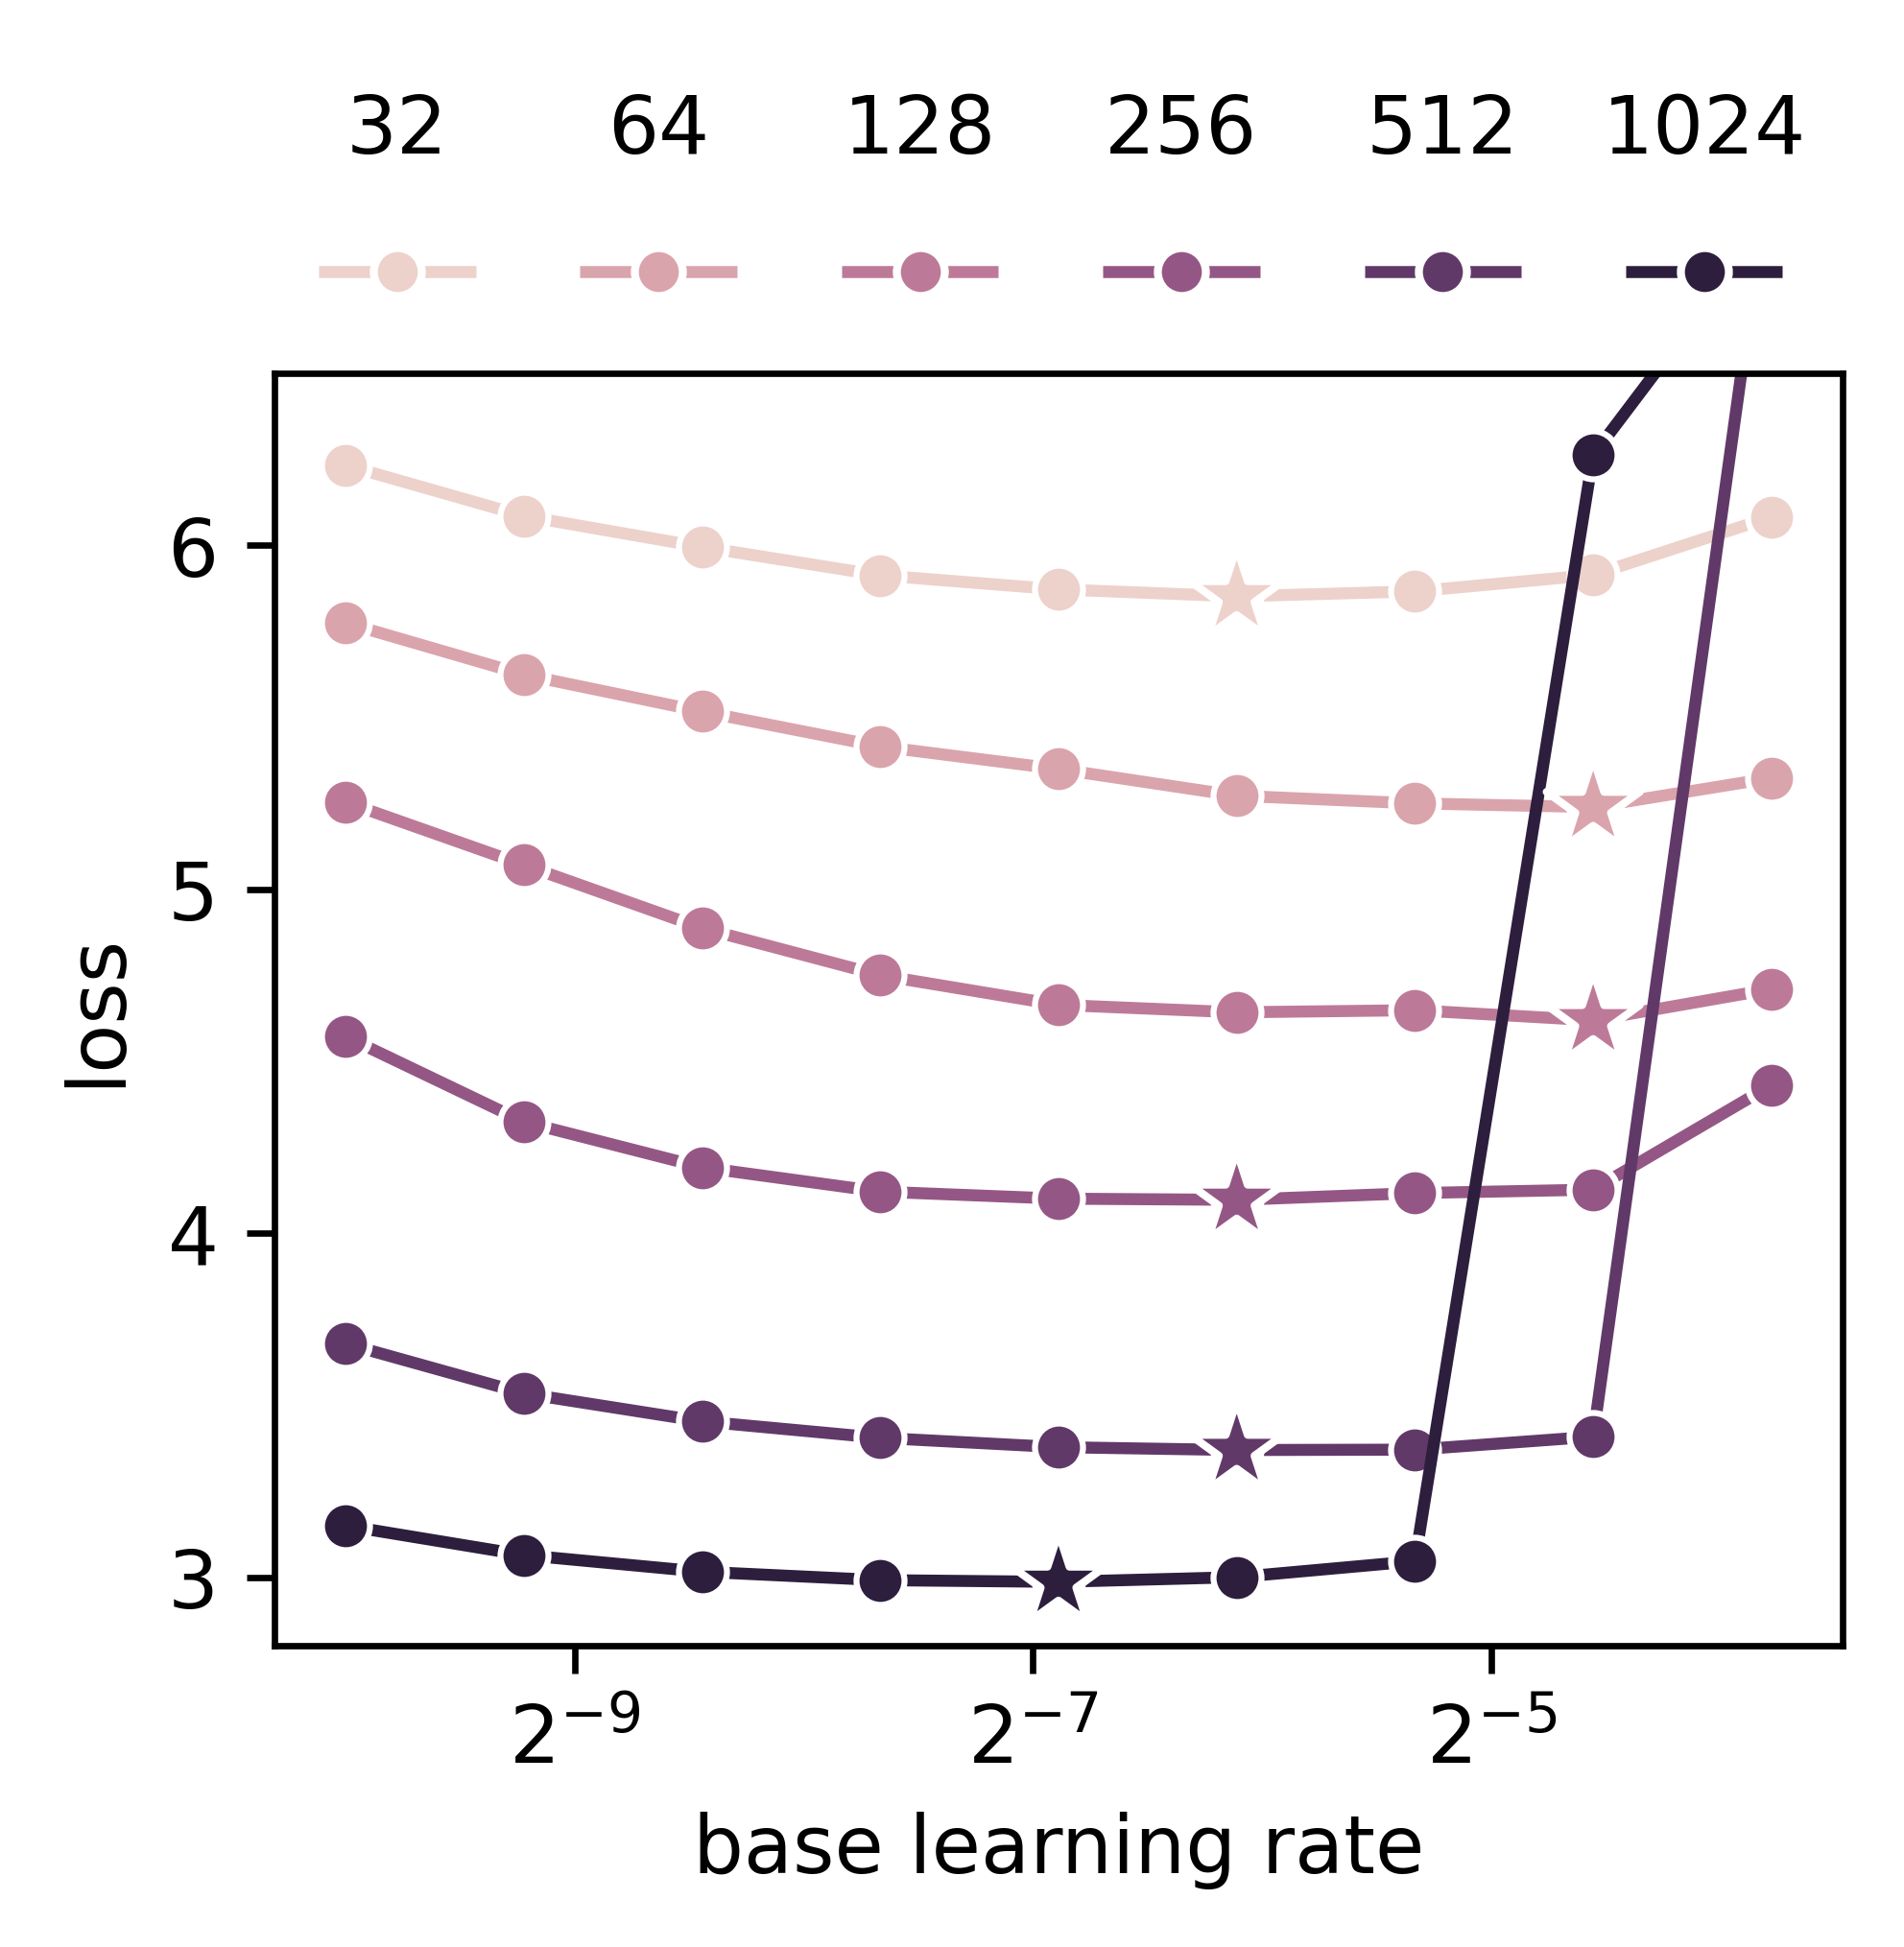

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

merged_run_df = pd.concat(
    [
        df_best_runs_not_relative.query("d_model == 1024"),
        df_best_runs_not_relative.query("full_length_training == False")
    ]
)
merged_optimal_lr_df = pd.concat([
    df_optimal_lrs_not_relative.query('d_model == 1024'),
    df_optimal_lrs_not_relative.query("full_length_training == False")
])


# final loss
sns.lineplot(merged_run_df,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    merged_optimal_lr_df,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)


ax.set_xscale('log', base=2)
# ax.set_xlim(2**7, 2**11)
ax.set_ylim(2.8, 6.5)

# labels
ax.set_xlabel('base learning rate')
ax.set_ylabel('loss')

# legend
two_row_legend(ax, x_offset=-0.005)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

# ax.set_title("Loss vs optimal base learning rate under muTransfer without relative lr schedule")

plt.tight_layout()
plt.show()

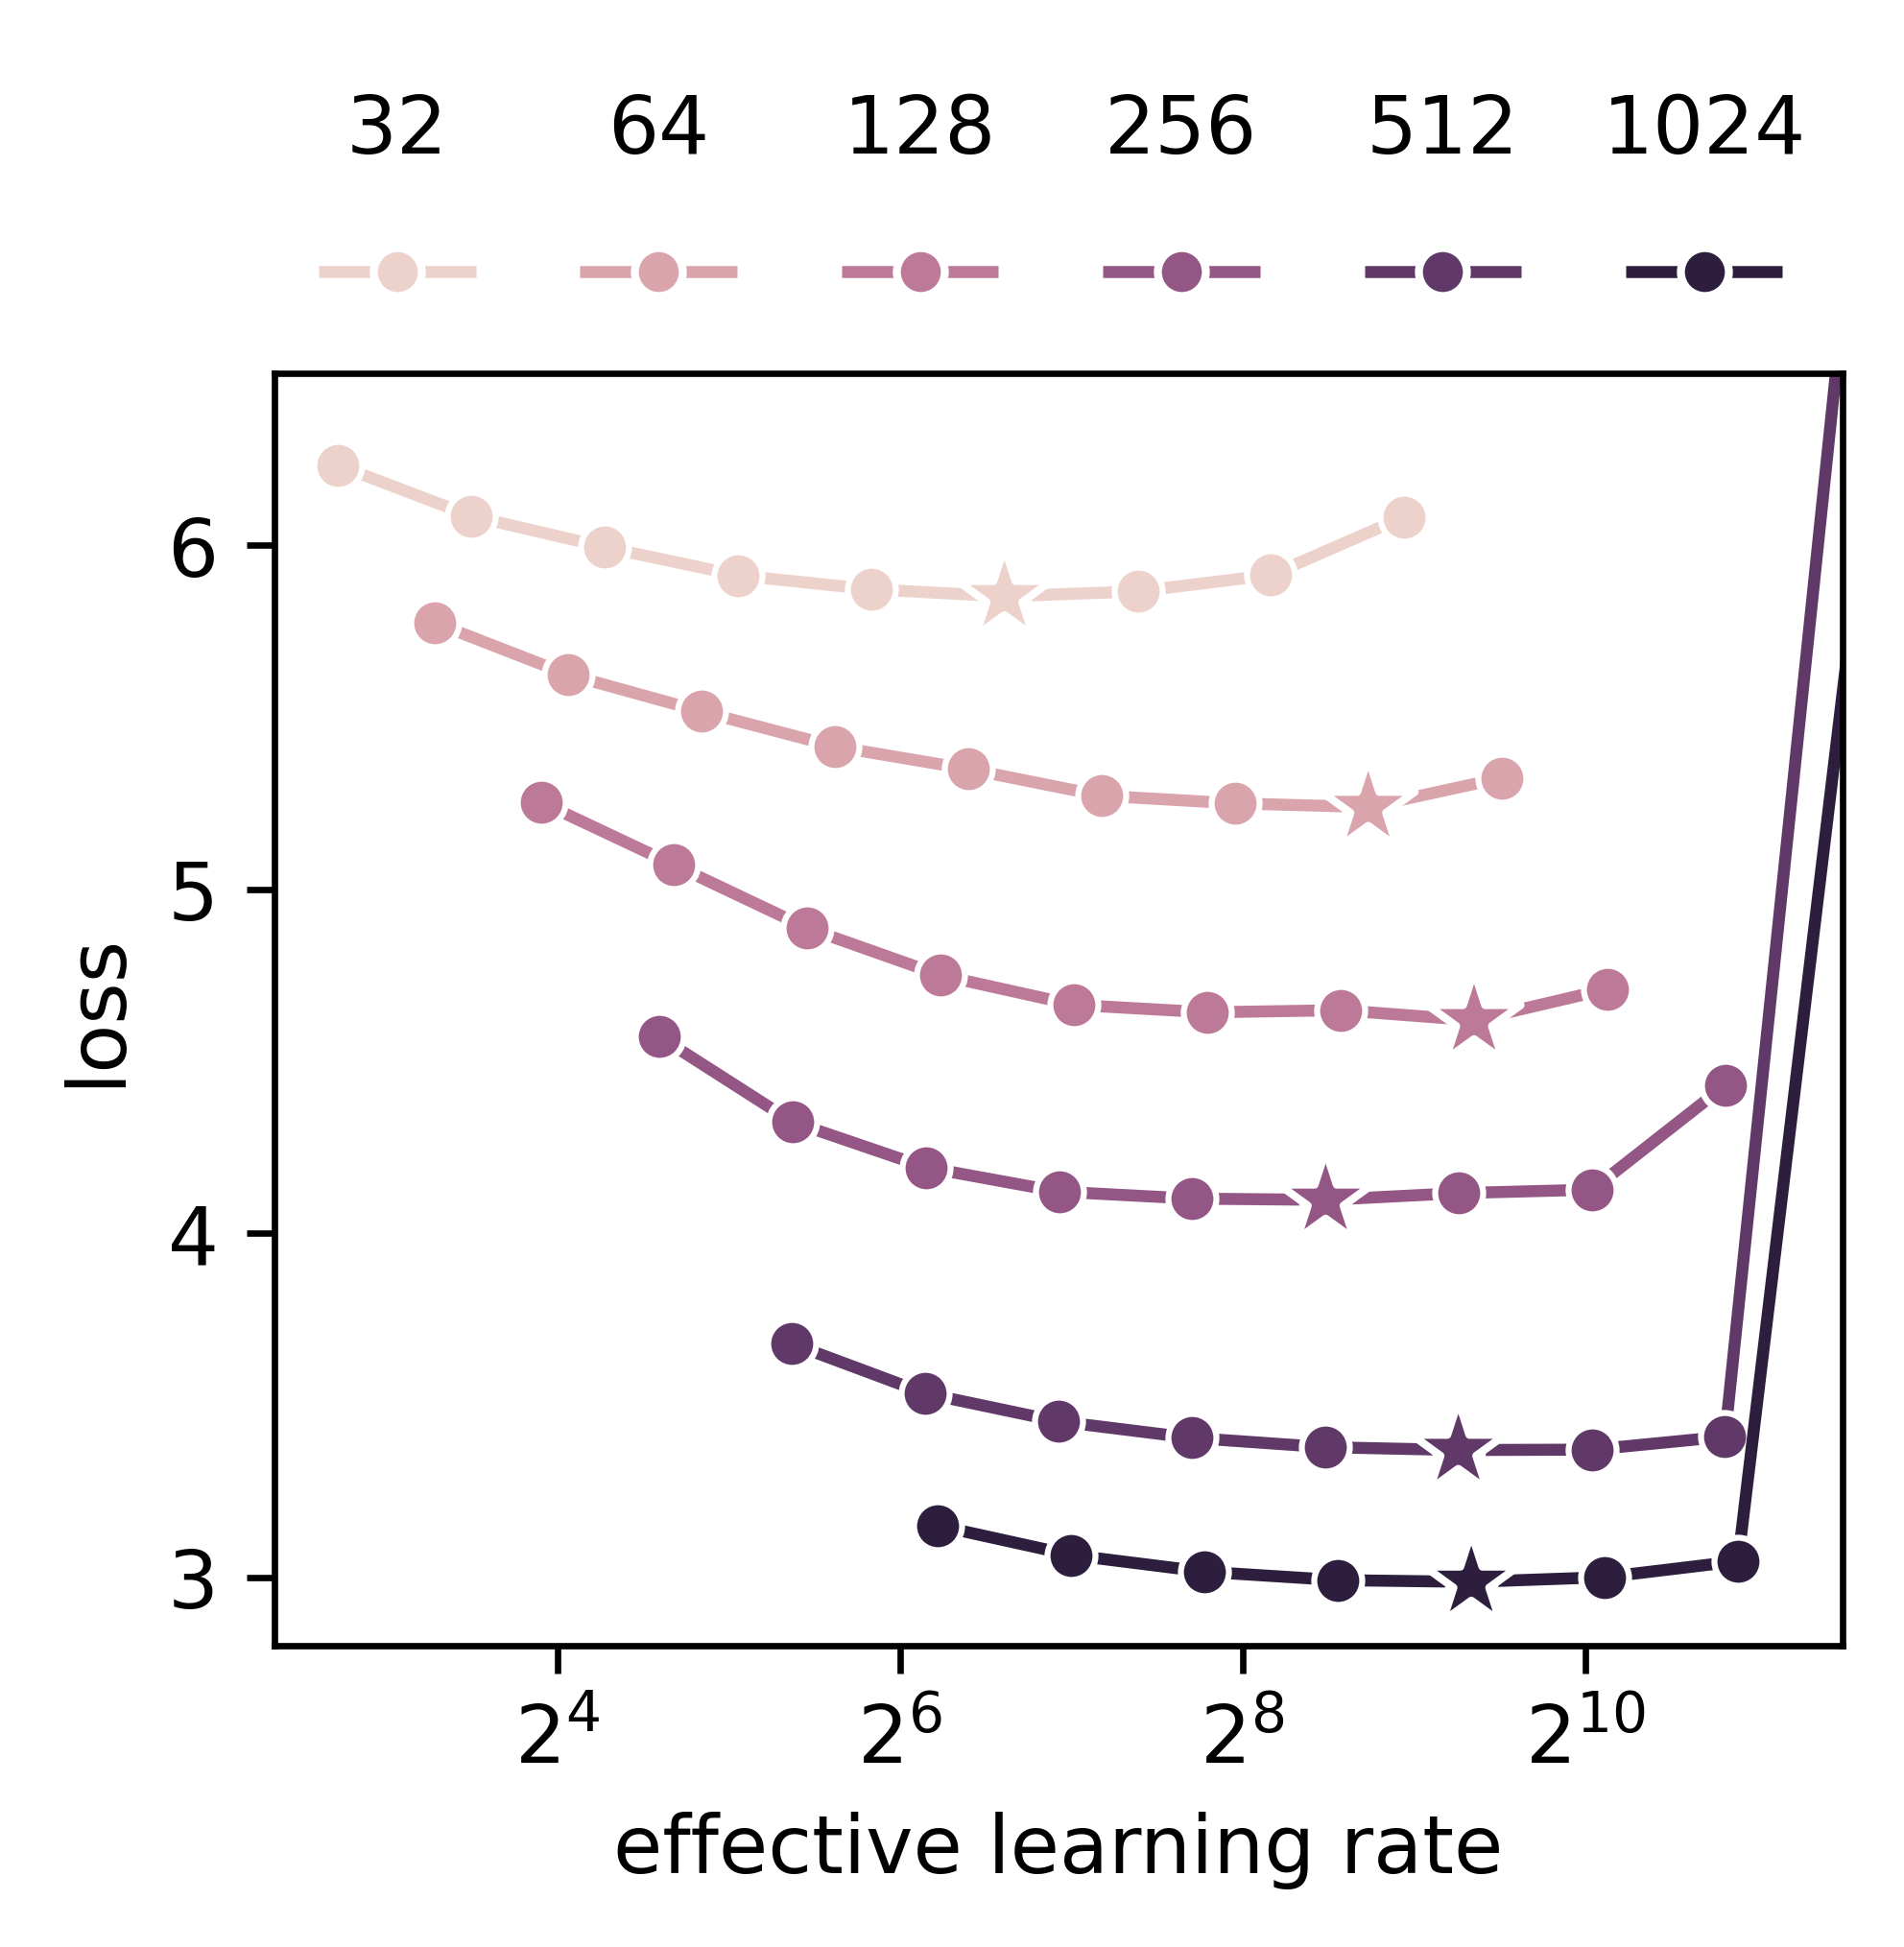

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

merged_run_df = pd.concat(
    [
        df_best_runs_not_relative.query("d_model == 1024"),
        df_best_runs_not_relative.query("full_length_training == False")
    ]
)
merged_optimal_lr_df = pd.concat([
    df_optimal_lrs_not_relative.query('d_model == 1024'),
    df_optimal_lrs_not_relative.query("full_length_training == False")
])


# final loss
sns.lineplot(merged_run_df,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='o',
    zorder=2,
    )

sns.scatterplot(
    merged_optimal_lr_df,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    hue_norm=LogNorm(),
    ax=ax,
    marker='*',
    legend=False,
    s=150,
    zorder=3,
)


ax.set_xscale('log', base=2)
ax.set_xlim(2**2.35, 2**11.5)
ax.set_ylim(2.8, 6.5)

# labels
ax.set_xlabel('effective learning rate')
ax.set_ylabel('loss')

# legend
two_row_legend(ax, x_offset=-0.005)
fig.subplots_adjust(top=0.8)  # leave room above the axes

legend = ax.legend()
legend.remove()

# ax.set_title("Loss vs optimal base learning rate under muTransfer without relative lr schedule")

plt.tight_layout()
plt.show()